#Ticket


In [1]:
!pip install ydata-profiling


ERROR: Operation cancelled by user


In [ ]:
# ── 1. Import Library ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport

In [ ]:
# ── 2. โหลด Dataset ─────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # เลือกไฟล์ customer_support_efficiency_escalation_dataset.csv

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

Saving customer_support_synthetic_v2.csv to customer_support_synthetic_v2.csv


In [ ]:
# ── 3. ดูโครงสร้างข้อมูลเบื้องต้น ──────────────────────────
print("=" * 60)
print("📌 Shape (แถว, คอลัมน์):", df.shape)
print("=" * 60)

print("\n📌 5 แถวแรก:")
display(df.head())

print("\n📌 ประเภทข้อมูลแต่ละคอลัมน์ (dtypes):")
print(df.dtypes)

print("\n📌 สรุปสถิติเบื้องต้น:")
display(df.describe(include="all"))

📌 Shape (แถว, คอลัมน์): (10000, 11)

📌 5 แถวแรก:


,ticket_id,ticket_type,priority,channel,customer_tenure_months,agent_experience_years,messages_count,avg_response_time_minutes,resolution_time_hours,escalated,customer_satisfaction_score
0,1,Technical,Medium,Phone,77,0.9,19,40.0,41.6,0,4
1,2,Other,Medium,Chat,91,1.2,21,26.5,31.6,1,3
2,3,Account,Low,Chat,38,5.2,3,18.7,11.2,0,5
3,4,Billing,High,Email,33,12.6,18,40.7,22.7,0,5
4,5,Product,Medium,Email,6,4.2,12,44.3,30.7,0,4



📌 ประเภทข้อมูลแต่ละคอลัมน์ (dtypes):
ticket_id                        int64
ticket_type                     object
priority                        object
channel                         object
customer_tenure_months           int64
agent_experience_years         float64
messages_count                   int64
avg_response_time_minutes      float64
resolution_time_hours          float64
escalated                        int64
customer_satisfaction_score      int64
dtype: object

📌 สรุปสถิติเบื้องต้น:


,ticket_id,ticket_type,priority,channel,customer_tenure_months,agent_experience_years,messages_count,avg_response_time_minutes,resolution_time_hours,escalated,customer_satisfaction_score
count,10000.00000,10000,10000,10000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,5,4,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Technical,Low,Chat,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2239,2933,3491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,NaN,NaN,NaN,60.389800,7.73484,13.764000,32.295010,24.085490,0.227100,4.153000
std,2886.89568,NaN,NaN,NaN,34.920959,4.19830,7.659606,9.560054,16.924029,0.418979,1.026887
min,1.00000,NaN,NaN,NaN,1.000000,0.50000,3.000000,1.000000,0.500000,0.000000,1.000000
25%,2500.75000,NaN,NaN,NaN,30.000000,4.10000,7.000000,25.700000,10.075000,0.000000,4.000000
50%,5000.50000,NaN,NaN,NaN,60.000000,7.70000,13.000000,32.200000,22.900000,0.000000,4.000000
75%,7500.25000,NaN,NaN,NaN,91.000000,11.40000,19.000000,39.000000,36.400000,0.000000,5.000000


In [ ]:
# ── 4. ตรวจสอบ Missing Values ───────────────────────────────
print("\n📌 Missing Values รายคอลัมน์:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
display(missing_df[missing_df["Missing Count"] > 0] if missing.sum() > 0
        else pd.DataFrame({"ผล": ["ไม่มี Missing Values ✅"]}))


📌 Missing Values รายคอลัมน์:


,ผล
0,ไม่มี Missing Values ✅


In [ ]:
# ── 5. ตรวจสอบ Duplicate Rows ────────────────────────────────
dup_count = df.duplicated().sum()
print(f"\n📌 Duplicate Rows: {dup_count} แถว"
      + (" ✅" if dup_count == 0 else " ⚠️ ควรตรวจสอบ"))


📌 Duplicate Rows: 0 แถว ✅


In [ ]:
# ── 6. แยกประเภทคอลัมน์ ────────────────────────────────────
num_cols  = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols  = df.select_dtypes(include=["object"]).columns.tolist()

# ลบ ticket_id ออกจาก num_cols (เป็น ID ไม่ใช่ Feature)
if "ticket_id" in num_cols:
    num_cols.remove("ticket_id")

print(f"\n📌 Numerical Columns  ({len(num_cols)}): {num_cols}")
print(f"📌 Categorical Columns ({len(cat_cols)}): {cat_cols}")


📌 Numerical Columns  (7): ['customer_tenure_months', 'agent_experience_years', 'messages_count', 'avg_response_time_minutes', 'resolution_time_hours', 'escalated', 'customer_satisfaction_score']
📌 Categorical Columns (3): ['ticket_type', 'priority', 'channel']


In [ ]:
# ── 7. Distribution ของ Categorical Features ─────────────────
print("\n📌 Value Counts ของ Categorical Features:")
for col in cat_cols:
    print(f"\n  [{col}]")
    print(df[col].value_counts())


📌 Value Counts ของ Categorical Features:

  [ticket_type]
ticket_type
Technical    2239
Product      2239
Billing      2018
Account      1766
Other        1738
Name: count, dtype: int64

  [priority]
priority
Low         2933
Medium      2819
High        2389
Critical    1859
Name: count, dtype: int64

  [channel]
channel
Chat     3491
Email    3353
Phone    3156
Name: count, dtype: int64



📌 Class Balance — escalated (Target Variable):
           Count      %
escalated              
0           7729  77.29
1           2271  22.71


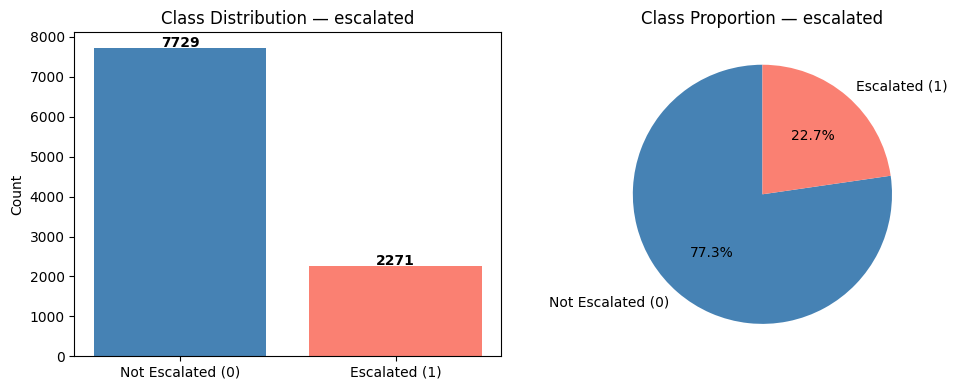

In [ ]:
# ── 8. Class Balance: ตัวแปรเป้าหมาย (escalated) ─────────────
print("\n📌 Class Balance — escalated (Target Variable):")
esc_counts = df["escalated"].value_counts()
esc_pct    = df["escalated"].value_counts(normalize=True) * 100
print(pd.DataFrame({"Count": esc_counts, "%": esc_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(["Not Escalated (0)", "Escalated (1)"],
            esc_counts.values, color=["steelblue", "salmon"])
axes[0].set_title("Class Distribution — escalated")
axes[0].set_ylabel("Count")
for i, v in enumerate(esc_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

axes[1].pie(esc_counts.values,
            labels=["Not Escalated (0)", "Escalated (1)"],
            autopct="%1.1f%%", colors=["steelblue", "salmon"],
            startangle=90)
axes[1].set_title("Class Proportion — escalated")
plt.tight_layout()
plt.show()

/tmp/ipykernel_5054/3557824008.py:14: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/3557824008.py:14: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/3557824008.py:14: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3586 (\N{THAI CHARACTER KHO KHAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3591 (\N{THAI CHARACTER NGO NGU}) missing from font(s) DejaVu Sans.
  f

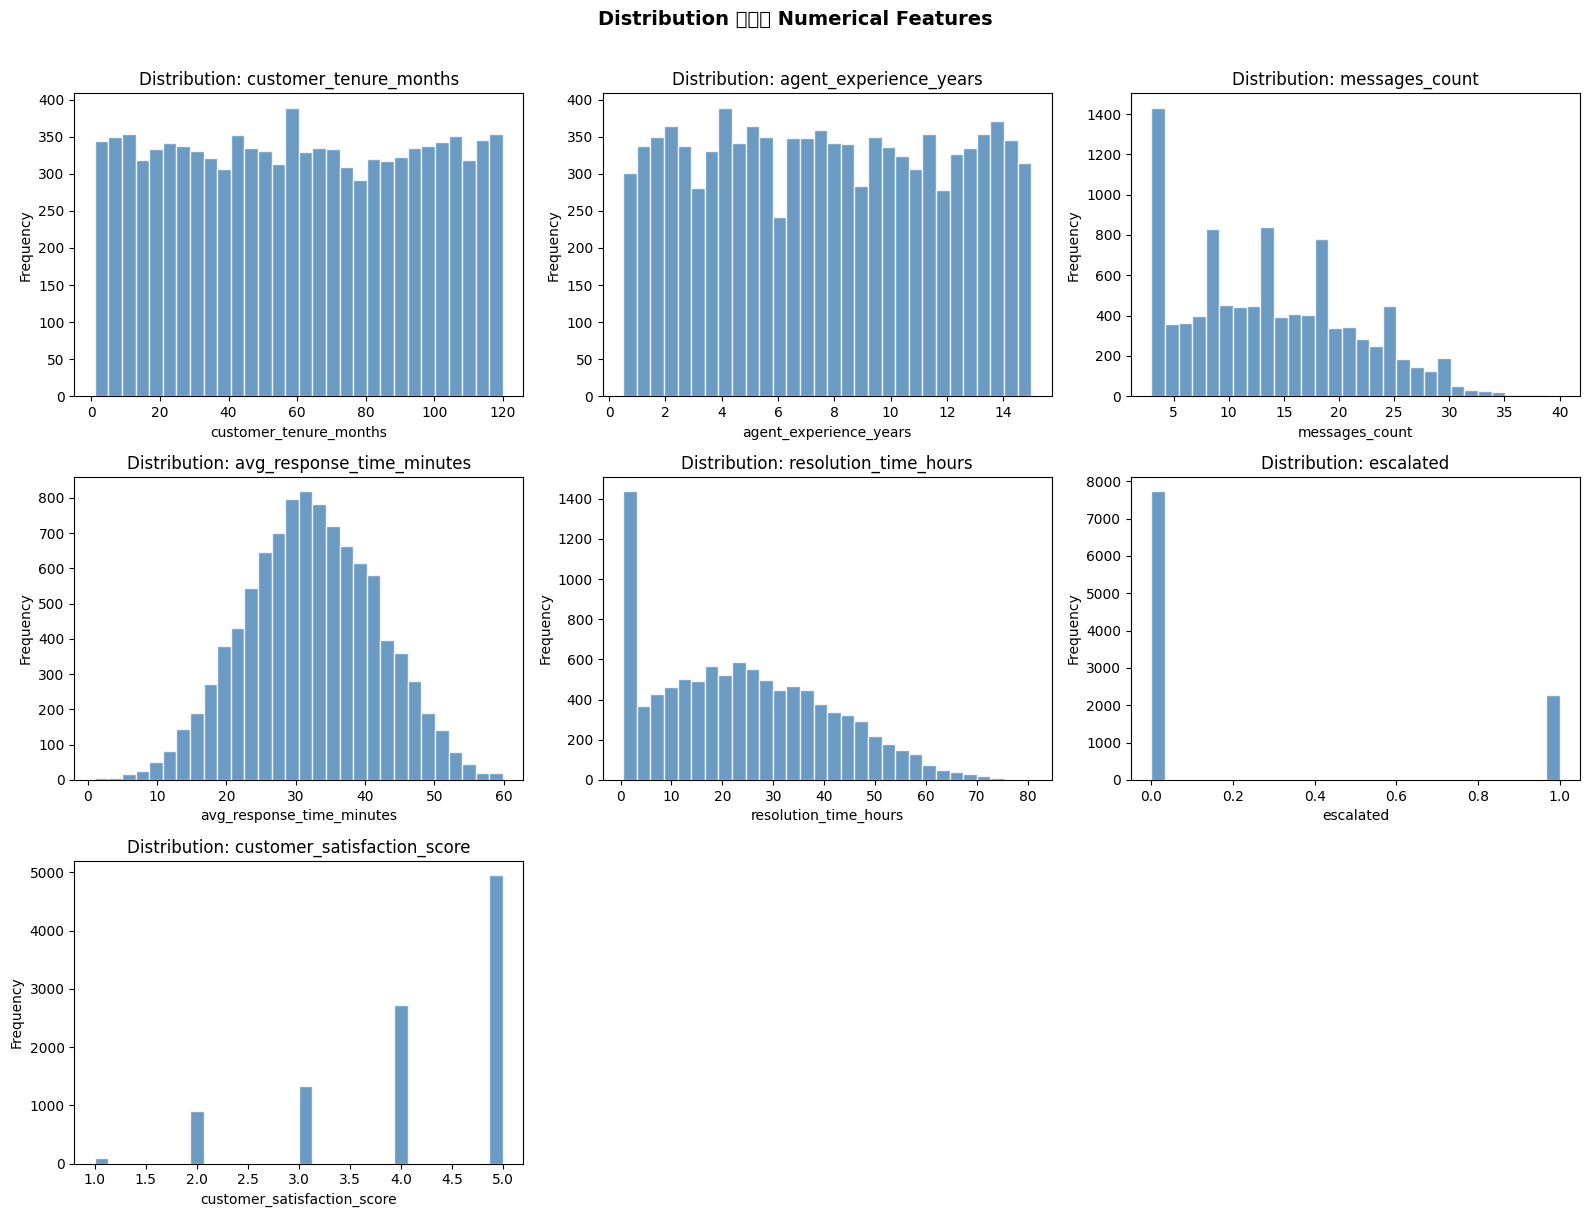

In [ ]:
# ── 9. Distribution ของ Numerical Features ────────────────────
n_cols = 3
n_rows = -(-len(num_cols) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"Distribution: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Distribution ของ Numerical Features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5054/2446091289.py:14: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/2446091289.py:14: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/2446091289.py:14: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/2446091289.py:14: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/2446091289.py:14: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_5054/2446091289.py:14: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3649 (\N{THAI CHARACTER SARA AE}) miss

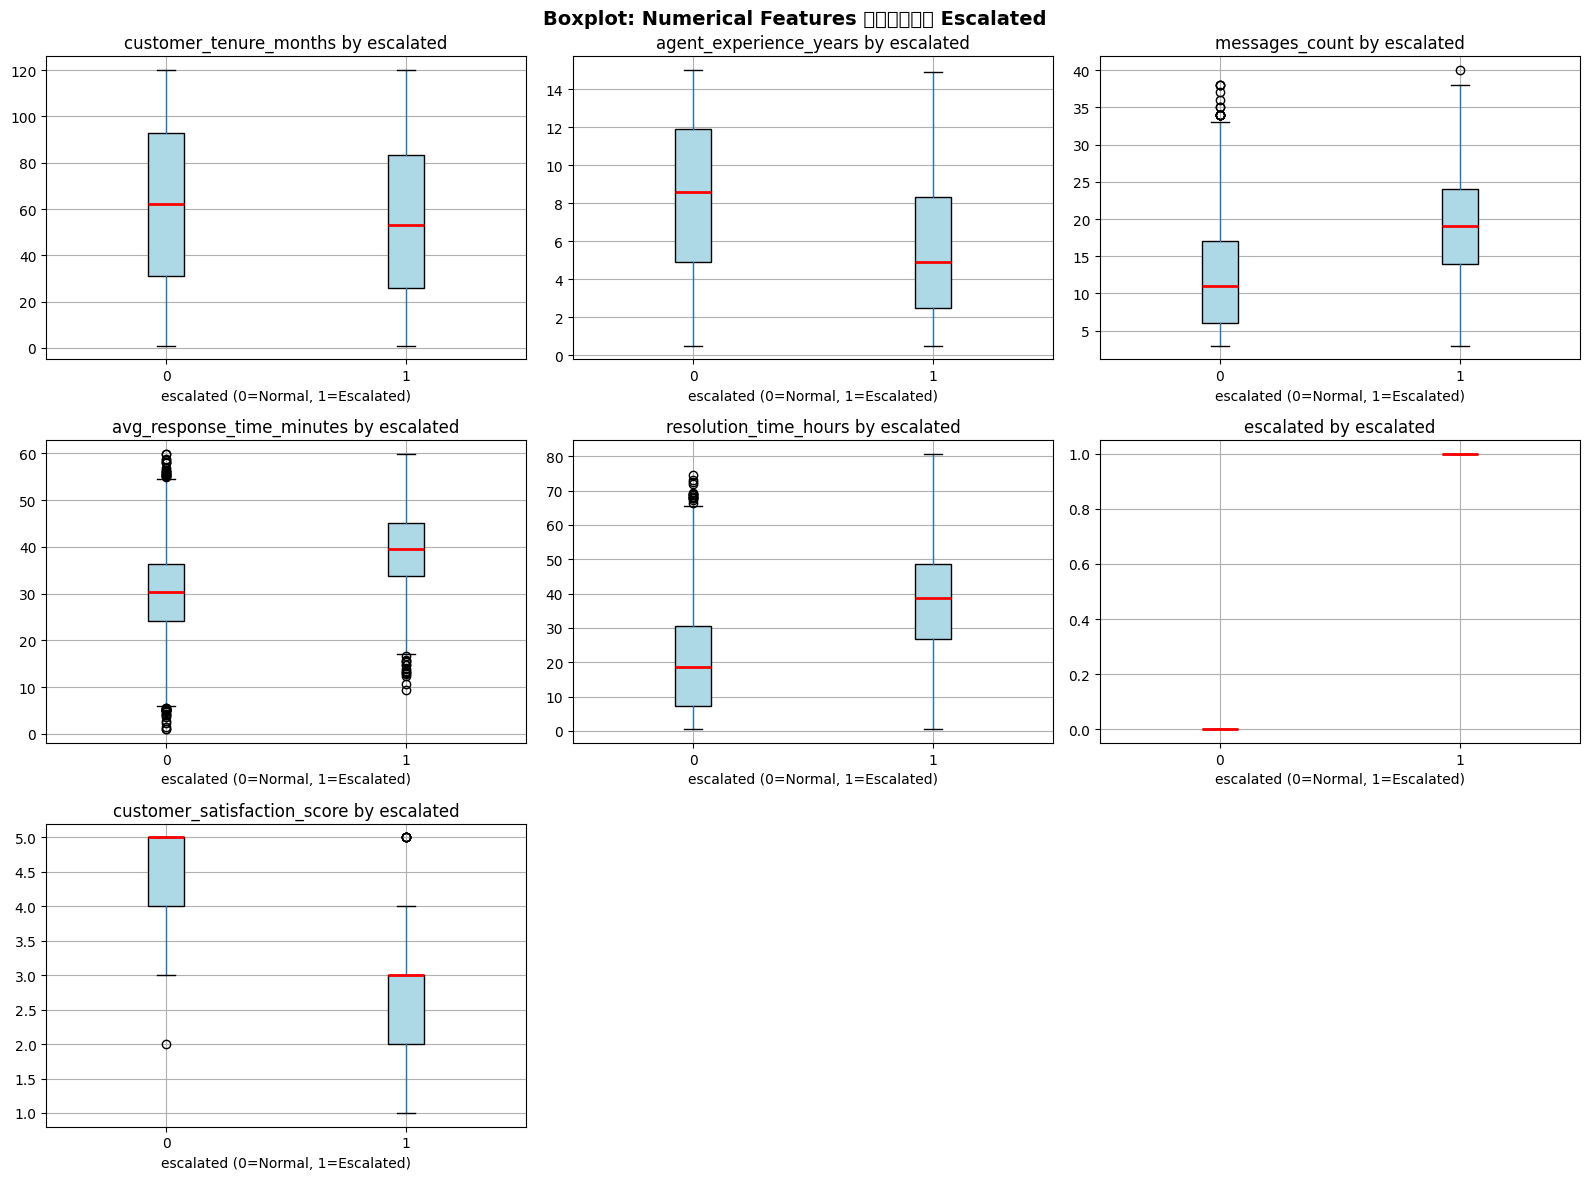

In [ ]:
# ── 10. Boxplot: Numerical Features แยกตาม escalated ──────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    df.boxplot(column=col, by="escalated", ax=axes[i],
               patch_artist=True,
               boxprops=dict(facecolor="lightblue"),
               medianprops=dict(color="red", linewidth=2))
    axes[i].set_title(f"{col} by escalated")
    axes[i].set_xlabel("escalated (0=Normal, 1=Escalated)")
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Boxplot: Numerical Features แยกตาม Escalated", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

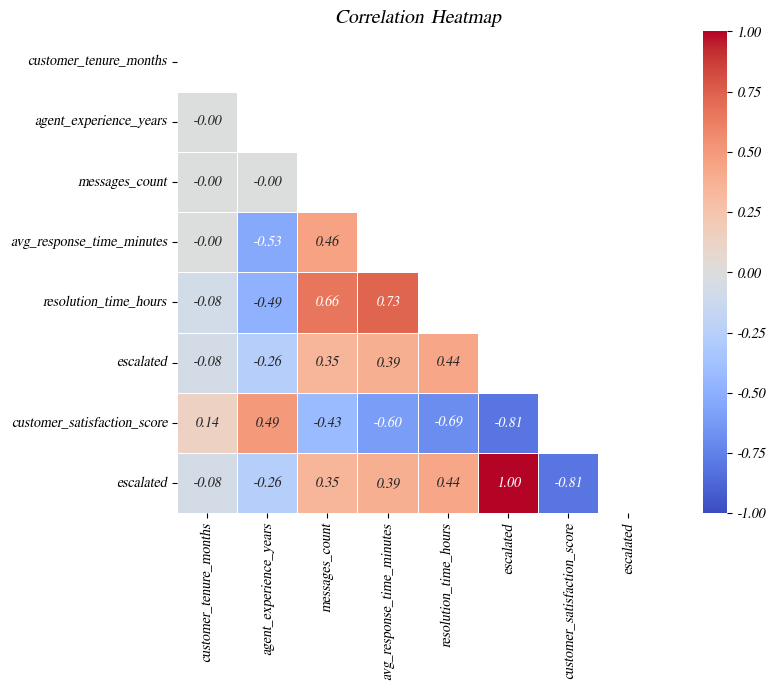

In [ ]:
# ── 11. Correlation Heatmap ────────────────────────────────────
plt.figure(figsize=(10, 7))
corr_matrix = df[num_cols + ["escalated"]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

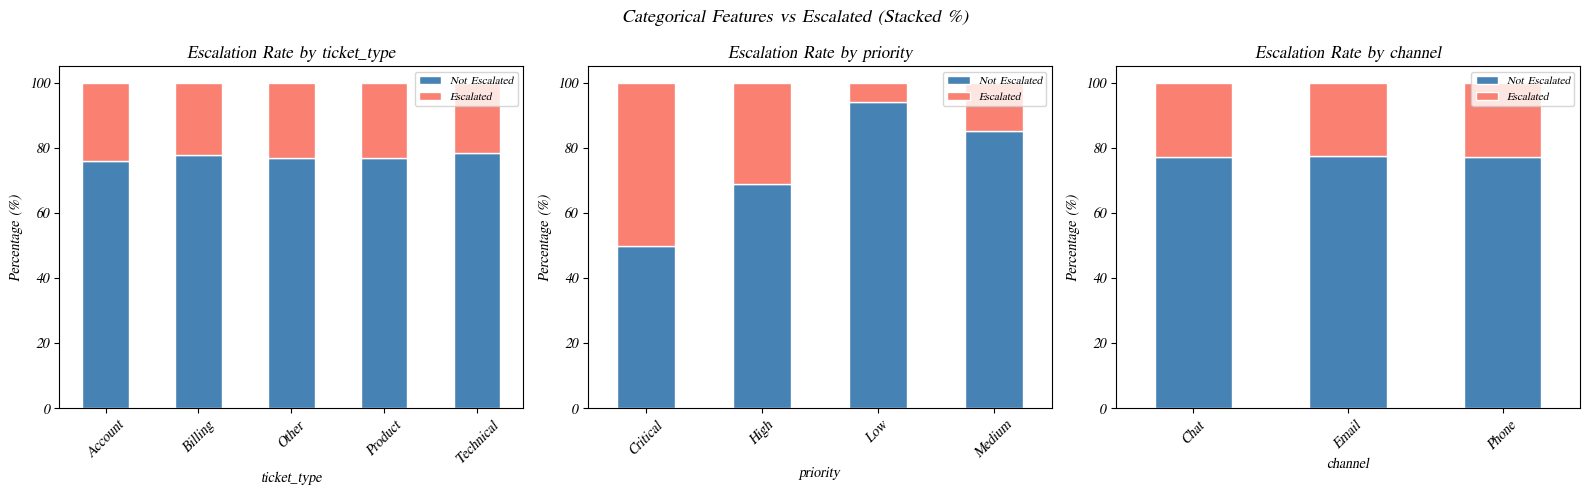

In [ ]:
# ── 12. Categorical Features กับ escalated (Stacked Bar) ────────
cat_features = ["ticket_type", "priority", "channel"]
fig, axes = plt.subplots(1, len(cat_features), figsize=(16, 5))
for ax, col in zip(axes, cat_features):
    ct = pd.crosstab(df[col], df["escalated"], normalize="index") * 100
    ct.columns = ["Not Escalated", "Escalated"]
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=["steelblue", "salmon"], edgecolor="white")
    ax.set_title(f"Escalation Rate by {col}")
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(loc="upper right", fontsize=8)
plt.suptitle("Categorical Features vs Escalated (Stacked %)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

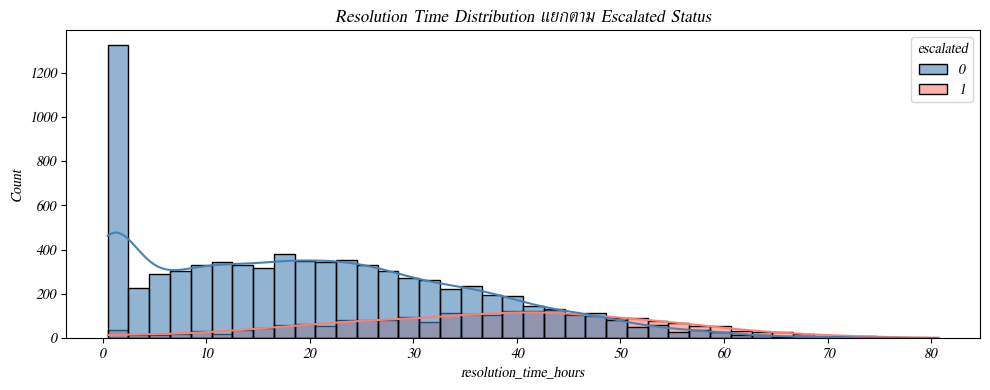

In [ ]:
# ── 13. resolution_time_hours Distribution ────────────────────
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="resolution_time_hours", hue="escalated",
             bins=40, kde=True, palette=["steelblue", "salmon"],
             alpha=0.6)
plt.title("Resolution Time Distribution แยกตาม Escalated Status")
plt.xlabel("resolution_time_hours")
plt.tight_layout()
plt.show()

In [ ]:
# ── 14. ydata_profiling — Full Report ─────────────────────────
print("\n⏳ กำลังสร้าง Profile Report... (อาจใช้เวลา 1-2 นาที)")


# ใช้ชื่อ DataFrame 'Country_data' ตามที่คุณตั้งไว้ในโค้ดก่อนหน้า
profile = ProfileReport(df, title="Customer Support Efficiency & Escalation — EDA Report")

# แสดงใน Colab Notebook
profile.to_notebook_iframe()

# บันทึกเป็น HTML (ดาวน์โหลดได้)
profile.to_file("eda_report.html")
print("\n✅ บันทึก EDA Report เป็น eda_report.html แล้ว")


⏳ กำลังสร้าง Profile Report... (อาจใช้เวลา 1-2 นาที)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 17.81it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✅ บันทึก EDA Report เป็น eda_report.html แล้ว


In [ ]:
# ── 15. สรุป Key Observations ─────────────────────────────────
print("\n" + "=" * 60)
print("📊 KEY OBSERVATIONS (ก่อนสร้างโมเดล)")
print("=" * 60)
print(f"  • Dataset: {df.shape[0]:,} แถว, {df.shape[1]} คอลัมน์")
print(f"  • Missing Values: {df.isnull().sum().sum()} ค่า")
print(f"  • Duplicate Rows: {dup_count} แถว")
print(f"  • Escalated Rate: {esc_pct[1]:.1f}%")
print(f"  • Numerical Features: {len(num_cols)} ตัว")
print(f"  • Categorical Features: {len(cat_cols)} ตัว")
print(f"  • Target (Classification): escalated")
print(f"  • Target (Regression)    : resolution_time_hours")
print("=" * 60)


📊 KEY OBSERVATIONS (ก่อนสร้างโมเดล)
  • Dataset: 10,000 แถว, 11 คอลัมน์
  • Missing Values: 0 ค่า
  • Duplicate Rows: 0 แถว
  • Escalated Rate: 22.7%
  • Numerical Features: 7 ตัว
  • Categorical Features: 3 ตัว
  • Target (Classification): escalated
  • Target (Regression)    : resolution_time_hours


In [ ]:
# ── ขั้นตอนที่ 1: Feature Selection ─────────────────────────
df_clean = df.drop(columns=['ticket_id', 'customer_satisfaction_score'])

print("Shape หลัง Feature Selection:", df_clean.shape)
# Output: (10000, 9)
print("คอลัมน์ที่เหลือ:", df_clean.columns.tolist())
# ['ticket_type', 'priority', 'channel', 'customer_tenure_months',
#  'agent_experience_years', 'messages_count', 'avg_response_time_minutes',
#  'resolution_time_hours', 'escalated']

Shape หลัง Feature Selection: (10000, 9)
คอลัมน์ที่เหลือ: ['ticket_type', 'priority', 'channel', 'customer_tenure_months', 'agent_experience_years', 'messages_count', 'avg_response_time_minutes', 'resolution_time_hours', 'escalated']


In [ ]:
# ── ขั้นตอนที่ 2: Ordinal Encoding ──────────────────────────
priority_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
df_clean['priority_encoded'] = df_clean['priority'].map(priority_map)
df_clean = df_clean.drop(columns=['priority'])

print(df_clean['priority_encoded'].value_counts().sort_index())
# 1 (Low)      2933
# 2 (Medium)   2819
# 3 (High)     2389
# 4 (Critical) 1859

priority_encoded
1    2933
2    2819
3    2389
4    1859
Name: count, dtype: int64


In [ ]:
# ── ขั้นตอนที่ 3: One-Hot Encoding ──────────────────────────
df_encoded = pd.get_dummies(df_clean, columns=['ticket_type', 'channel'], drop_first=False)

print("Shape หลัง One-Hot Encoding:", df_encoded.shape)
# Output: (10000, 15)
# ticket_type → 5 columns: Account, Billing, Other, Product, Technical
# channel     → 3 columns: Chat, Email, Phone

Shape หลัง One-Hot Encoding: (10000, 15)


In [ ]:
print("คอลัมน์หลัง One-Hot Encoding:")
print(df_encoded.columns.tolist())

คอลัมน์หลัง One-Hot Encoding:
['customer_tenure_months', 'agent_experience_years', 'messages_count', 'avg_response_time_minutes', 'resolution_time_hours', 'escalated', 'priority_encoded', 'ticket_type_Account', 'ticket_type_Billing', 'ticket_type_Other', 'ticket_type_Product', 'ticket_type_Technical', 'channel_Chat', 'channel_Email', 'channel_Phone']


In [ ]:
from sklearn.model_selection import train_test_split

# ── โมเดล 1: Classification (escalated) ──────────────────────
feature_cols_clf = [
    'priority_encoded', 'avg_response_time_minutes', 'messages_count',
    'agent_experience_years', 'customer_tenure_months',
    'ticket_type_Account', 'ticket_type_Billing', 'ticket_type_Other',
    'ticket_type_Product', 'ticket_type_Technical',
    'channel_Chat', 'channel_Email', 'channel_Phone'
]

X_clf = df_encoded[feature_cols_clf]
y_clf = df_encoded['escalated']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf          # รักษาสัดส่วน escalated ใน train/test
)

print(f"Classification — Train: {X_train_c.shape}, Test: {X_test_c.shape}")
# Train: (8000, 13), Test: (2000, 13)
print(f"Escalated ratio in Train: {y_train_c.mean():.3f}")
print(f"Escalated ratio in Test : {y_test_c.mean():.3f}")
# ทั้งสองชุดควรได้ ratio ≈ 0.227 เท่ากัน


# ── โมเดล 2: Regression (resolution_time_hours) ──────────────
feature_cols_reg = [
    'priority_encoded', 'messages_count', 'avg_response_time_minutes',
    'agent_experience_years', 'customer_tenure_months',
    'ticket_type_Account', 'ticket_type_Billing', 'ticket_type_Other',
    'ticket_type_Product', 'ticket_type_Technical',
    'channel_Chat', 'channel_Email', 'channel_Phone'
]

X_reg = df_encoded[feature_cols_reg]
y_reg = df_encoded['resolution_time_hours']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print(f"Regression — Train: {X_train_r.shape}, Test: {X_test_r.shape}")
# Train: (8000, 13), Test: (2000, 13)
print(f"Resolution Time mean (Train): {y_train_r.mean():.2f} ชม.")
print(f"Resolution Time mean (Test) : {y_test_r.mean():.2f} ชม.")

Classification — Train: (8000, 13), Test: (2000, 13)
Escalated ratio in Train: 0.227
Escalated ratio in Test : 0.227
Regression — Train: (8000, 13), Test: (2000, 13)
Resolution Time mean (Train): 24.08 ชม.
Resolution Time mean (Test) : 24.09 ชม.


#Modeling

In [2]:
# ============================================================
# MODELING — Decision Tree Classifier & Linear Regression
# ============================================================

import warnings
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)
warnings.filterwarnings('ignore')


In [3]:
# ============================================================
# โมเดล 1: Decision Tree Classifier (escalated)
# ============================================================
print("=" * 60)
print("โมเดล 1: Decision Tree Classifier (escalated)")
print("=" * 60)

clf = DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

# ── ผลประเมิน ────────────────────────────────────────────────
print(f"\nAccuracy : {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"Recall   : {recall_score(y_test_c, y_pred_c):.4f}")
print(f"F1-score : {f1_score(y_test_c, y_pred_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c,
      target_names=['Not Escalated (0)', 'Escalated (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))

# ── Feature Importance ───────────────────────────────────────
fi = pd.Series(clf.feature_importances_,
               index=feature_cols_clf).sort_values(ascending=False)
print("\nFeature Importance:")
print(fi[fi > 0])

# ── Plot Feature Importance ──────────────────────────────────
plt.figure(figsize=(10, 5))
fi[fi > 0].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree Classifier')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Plot Decision Tree ───────────────────────────────────────
plt.figure(figsize=(20, 8))
plot_tree(clf,
          feature_names=feature_cols_clf,
          class_names=['Not Escalated', 'Escalated'],
          filled=True, rounded=True, fontsize=9)
plt.title('Decision Tree (max_depth=5)')
plt.tight_layout()
plt.show()

โมเดล 1: Decision Tree Classifier (escalated)


NameError: name 'X_train_c' is not defined

In [ ]:
# ============================================================
# โมเดล 2: Multiple Linear Regression (resolution_time_hours)
# ============================================================
print("\n" + "=" * 60)
print("โมเดล 2: Multiple Linear Regression (resolution_time_hours)")
print("=" * 60)

reg = LinearRegression()
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

# ── ผลประเมิน ────────────────────────────────────────────────
mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print(f"\nMAE  : {mae:.4f} ชั่วโมง")
print(f"RMSE : {rmse:.4f} ชั่วโมง")
print(f"R²   : {r2:.4f}")

# ── Coefficients ─────────────────────────────────────────────
coef = pd.Series(reg.coef_, index=feature_cols_reg).sort_values(ascending=False)
print(f"\nIntercept: {reg.intercept_:.4f}")
print("\nCoefficients (เรียงจากมากไปน้อย):")
print(coef)

# ── Plot: Actual vs Predicted ────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.xlabel('Actual Resolution Time (hours)')
plt.ylabel('Predicted Resolution Time (hours)')
plt.title(f'Actual vs Predicted — Linear Regression (R² = {r2:.4f})')
plt.tight_layout()
plt.show()

# ── Plot: Residuals ──────────────────────────────────────────
residuals = y_test_r - y_pred_r
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ============================================================
# สรุปผลโมเดลทั้งสอง
# ============================================================
print("\n" + "=" * 60)
print("📊 สรุปผลโมเดลทั้งสอง")
print("=" * 60)
print(f"[Classification] Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"                 Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"                 Recall   : {recall_score(y_test_c, y_pred_c):.4f}")
print(f"                 F1-score : {f1_score(y_test_c, y_pred_c):.4f}")
print(f"[Regression]     MAE      : {mae:.4f} ชม.")
print(f"                 RMSE     : {rmse:.4f} ชม.")
print(f"                 R²       : {r2:.4f}")
print("=" * 60)

# รัน model อื่นๆ

In [ ]:
# ============================================================
# MODELING (ปรับปรุง) — Decision Tree + Gradient Boosting
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             mean_absolute_error, mean_squared_error, r2_score)
import warnings
warnings.filterwarnings('ignore')

โมเดล 1: Decision Tree Classifier (escalated)

Accuracy : 0.7335
Precision: 0.4454
Recall   : 0.7093
F1-score : 0.5472

Classification Report:
                   precision    recall  f1-score   support

Not Escalated (0)       0.90      0.74      0.81      1546
    Escalated (1)       0.45      0.71      0.55       454

         accuracy                           0.73      2000
        macro avg       0.67      0.72      0.68      2000
     weighted avg       0.79      0.73      0.75      2000

Confusion Matrix:
[[1145  401]
 [ 132  322]]

Feature Importance:
avg_response_time_minutes    0.478932
priority_encoded             0.183418
agent_experience_years       0.147877
customer_tenure_months       0.073988
messages_count               0.070858
ticket_type_Technical        0.009925
channel_Phone                0.009539
ticket_type_Other            0.009527
ticket_type_Account          0.007384
ticket_type_Billing          0.004935
channel_Chat                 0.001831
channel_Email   

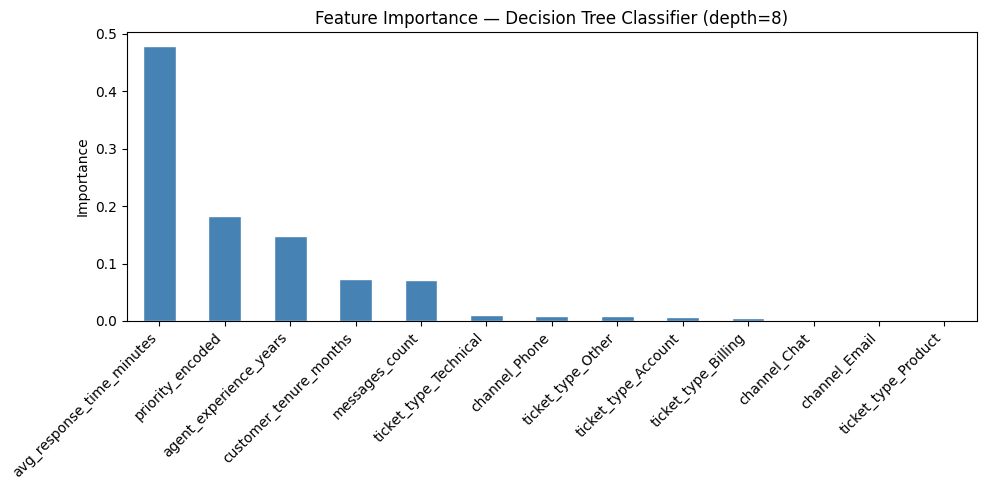

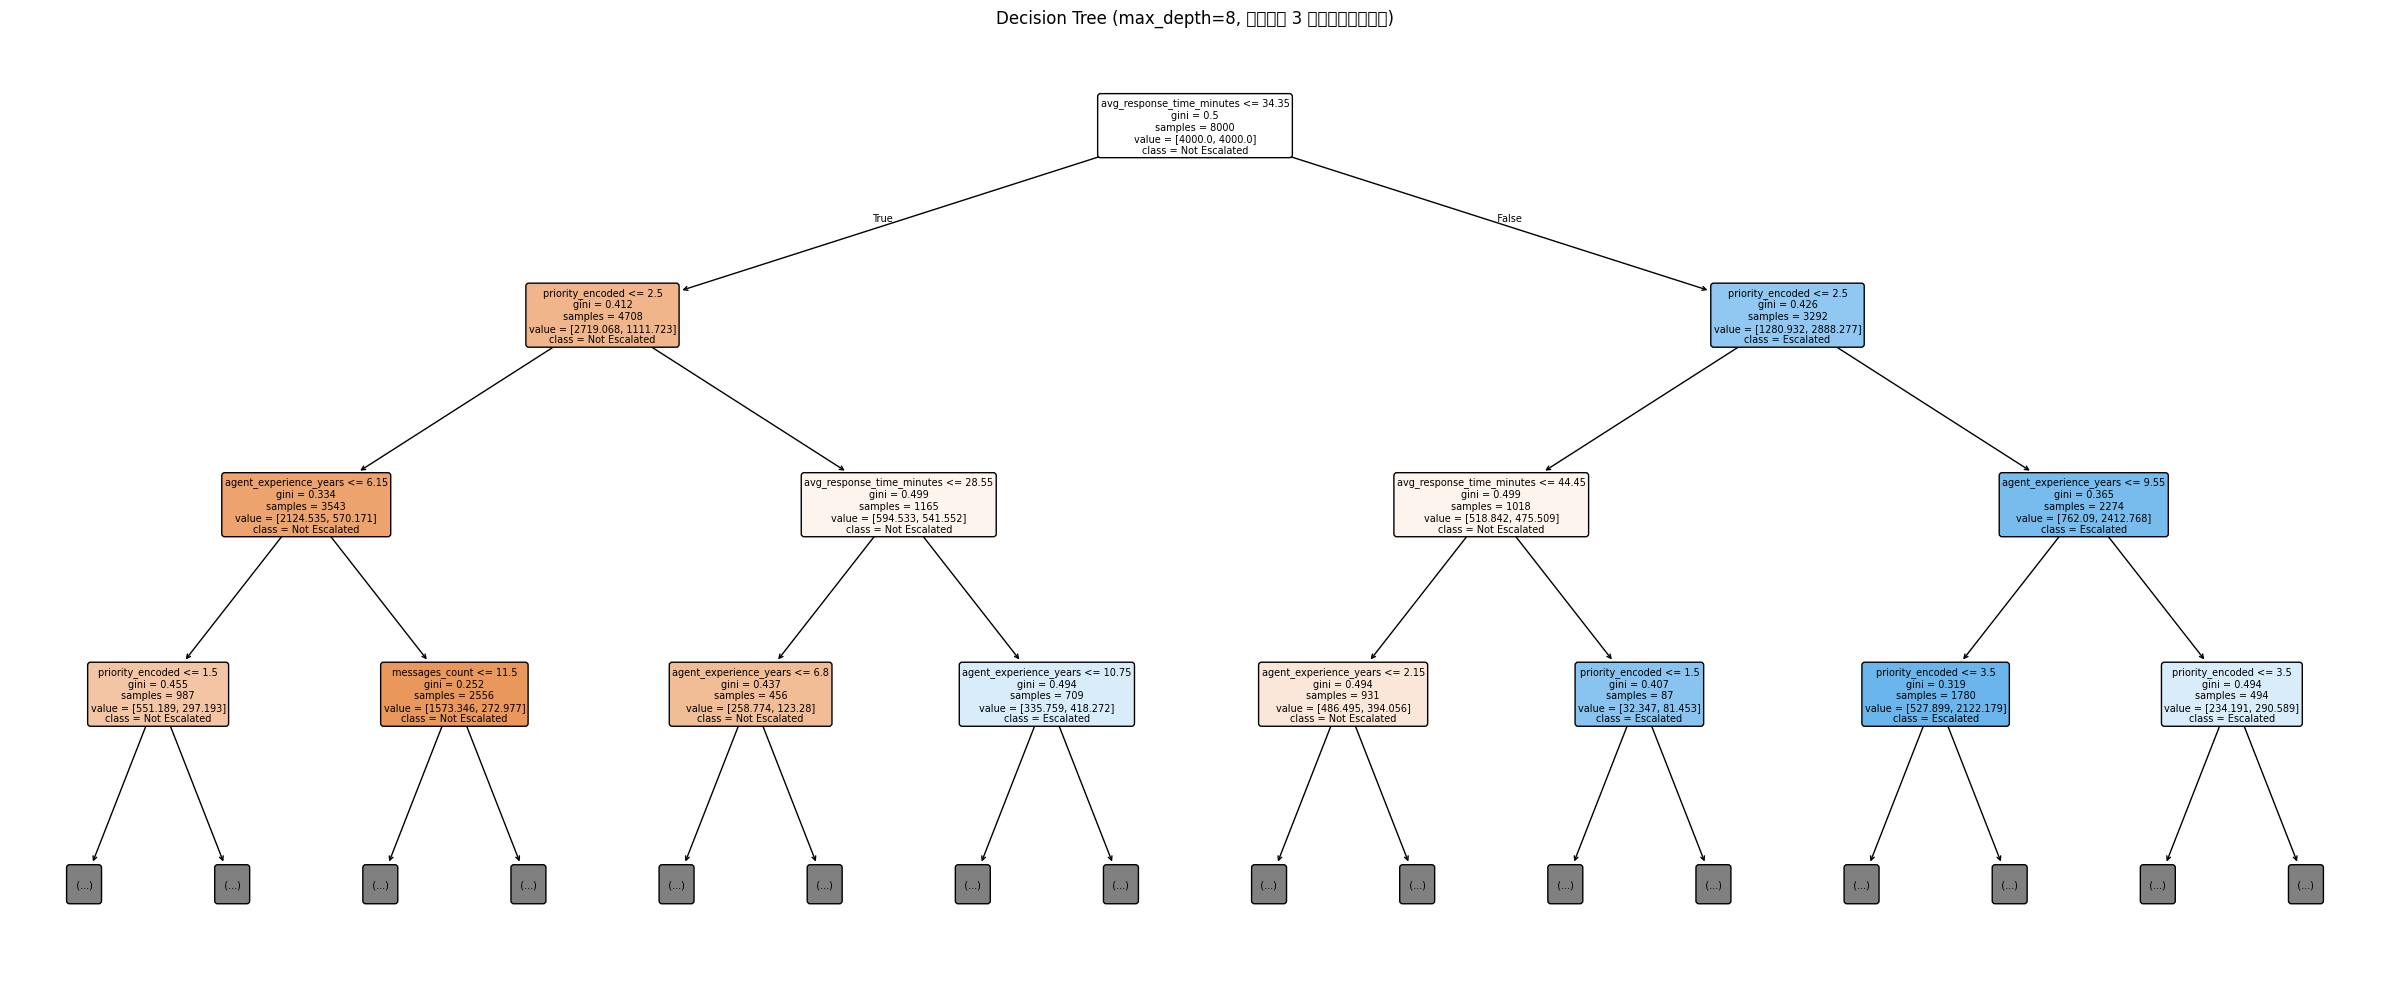

In [ ]:
# ============================================================
# โมเดล 1: Decision Tree Classifier (max_depth=8)
# ============================================================
print("=" * 60)
print("โมเดล 1: Decision Tree Classifier (escalated)")
print("=" * 60)

clf = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print(f"\nAccuracy : {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"Recall   : {recall_score(y_test_c, y_pred_c):.4f}")
print(f"F1-score : {f1_score(y_test_c, y_pred_c):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c,
      target_names=['Not Escalated (0)', 'Escalated (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))

# ── Feature Importance ───────────────────────────────────────
fi = pd.Series(clf.feature_importances_,
               index=feature_cols_clf).sort_values(ascending=False)
print("\nFeature Importance:")
print(fi[fi > 0])

# ── Plot Feature Importance ──────────────────────────────────
plt.figure(figsize=(10, 5))
fi[fi > 0].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree Classifier (depth=8)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Plot Decision Tree ───────────────────────────────────────
plt.figure(figsize=(24, 10))
plot_tree(clf,
          feature_names=feature_cols_clf,
          class_names=['Not Escalated', 'Escalated'],
          filled=True, rounded=True, fontsize=7,
          max_depth=3)   # แสดงแค่ 3 ระดับแรกให้ดูง่าย
plt.title('Decision Tree (max_depth=8, แสดง 3 ระดับแรก)')
plt.tight_layout()
plt.show()



โมเดล 2: Gradient Boosting Regressor (resolution_time_hours)

MAE  : 5.9814 ชั่วโมง
RMSE : 7.6309 ชั่วโมง
R²   : 0.8004

Feature Importance (Regression):
priority_encoded             0.489115
agent_experience_years       0.224856
avg_response_time_minutes    0.199743
messages_count               0.071994
customer_tenure_months       0.013466
dtype: float64


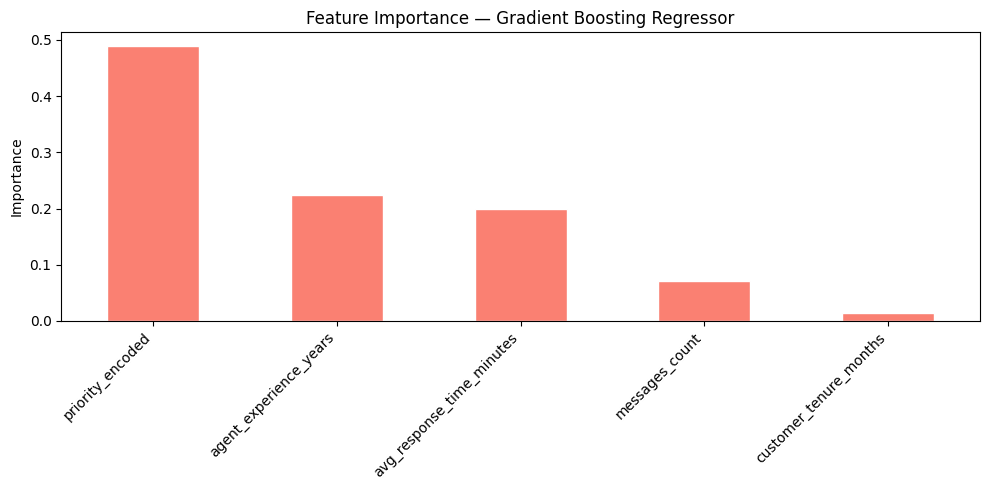

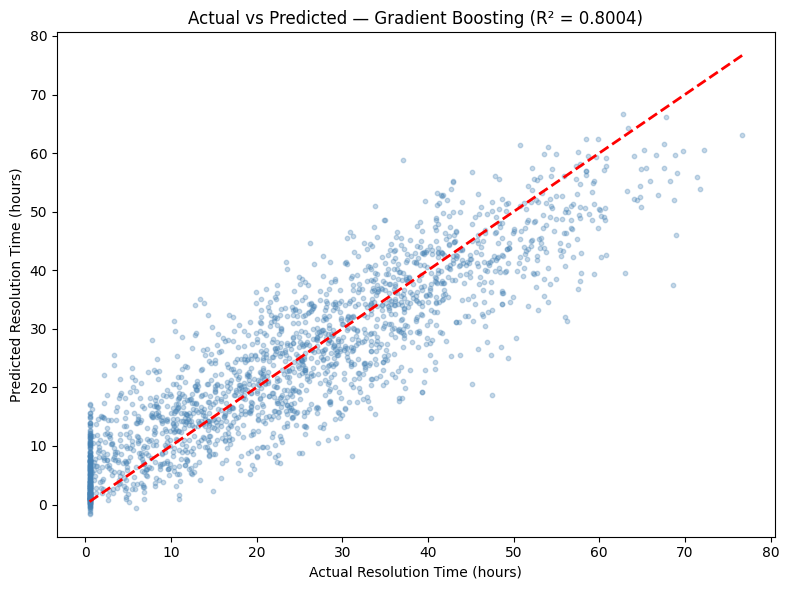

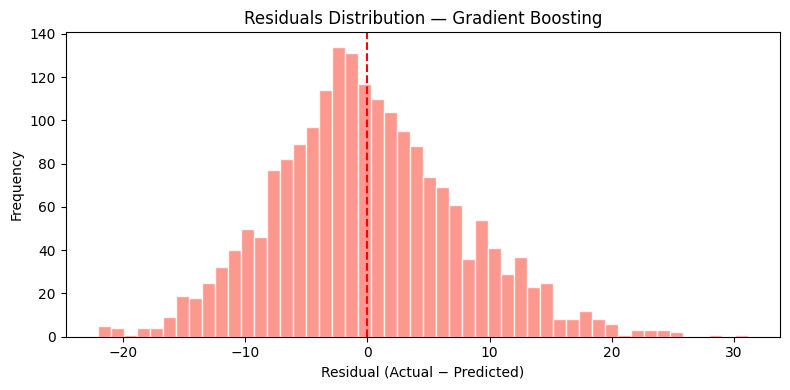

In [ ]:
# ============================================================
# โมเดล 2: Gradient Boosting Regressor
# ============================================================
print("\n" + "=" * 60)
print("โมเดล 2: Gradient Boosting Regressor (resolution_time_hours)")
print("=" * 60)

reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)
y_pred_r = reg.predict(X_test_r)

mae  = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2   = r2_score(y_test_r, y_pred_r)

print(f"\nMAE  : {mae:.4f} ชั่วโมง")
print(f"RMSE : {rmse:.4f} ชั่วโมง")
print(f"R²   : {r2:.4f}")

# ── Feature Importance (Gradient Boosting) ───────────────────
fi_reg = pd.Series(reg.feature_importances_,
                   index=feature_cols_reg).sort_values(ascending=False)
print("\nFeature Importance (Regression):")
print(fi_reg[fi_reg > 0.01])

# ── Plot Feature Importance ──────────────────────────────────
plt.figure(figsize=(10, 5))
fi_reg[fi_reg > 0.01].plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Feature Importance — Gradient Boosting Regressor')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── Plot: Actual vs Predicted ────────────────────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.xlabel('Actual Resolution Time (hours)')
plt.ylabel('Predicted Resolution Time (hours)')
plt.title(f'Actual vs Predicted — Gradient Boosting (R² = {r2:.4f})')
plt.tight_layout()
plt.show()

# ── Plot: Residuals ──────────────────────────────────────────
residuals = y_test_r - y_pred_r
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=50, color='salmon', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution — Gradient Boosting')
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# สรุปผลโมเดลทั้งสอง
# ============================================================
print("\n" + "=" * 60)
print("📊 สรุปผลโมเดลทั้งสอง")
print("=" * 60)
print(f"[Classification] Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}")
print(f"                 Precision: {precision_score(y_test_c, y_pred_c):.4f}")
print(f"                 Recall   : {recall_score(y_test_c, y_pred_c):.4f}")
print(f"                 F1-score : {f1_score(y_test_c, y_pred_c):.4f}")
print(f"[Regression]     MAE      : {mae:.4f} ชม.")
print(f"                 RMSE     : {rmse:.4f} ชม.")
print(f"                 R²       : {r2:.4f}")
print("=" * 60)


📊 สรุปผลโมเดลทั้งสอง
[Classification] Accuracy : 0.7335
                 Precision: 0.4454
                 Recall   : 0.7093
                 F1-score : 0.5472
[Regression]     MAE      : 5.9814 ชม.
                 RMSE     : 7.6309 ชม.
                 R²       : 0.8004


# Decision tree hyper parmeter tuning

⏳ กำลังรัน GridSearchCV... (อาจใช้เวลา 2-5 นาที)
Fitting 5 folds for each of 160 candidates, totalling 800 fits

✅ Best Parameters:
{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1-score: 0.5430

📊 เปรียบเทียบ Before vs After Hyperparameter Tuning
Metric           Before      After     Change
---------------------------------------------
Accuracy         0.7335     0.7250 ▼ 0.0085
Precision        0.4454     0.4372 ▼ 0.0082
Recall           0.7093     0.7357 ▲ 0.0264
F1-score         0.5472     0.5484 ▲ 0.0013

Classification Report (After Tuning):
                   precision    recall  f1-score   support

Not Escalated (0)       0.90      0.72      0.80      1546
    Escalated (1)       0.44      0.74      0.55       454

         accuracy                           0.72      2000
        macro avg       0.67      0.73      0.68      2000
     weighted avg       0.80      0.72      0.74      2000

Confusion Matrix (After Tuning):
[[1116 

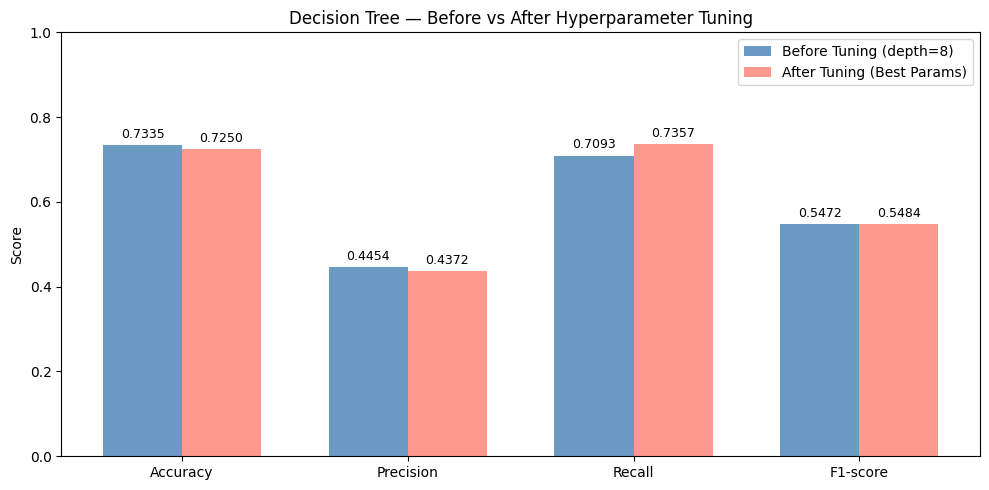

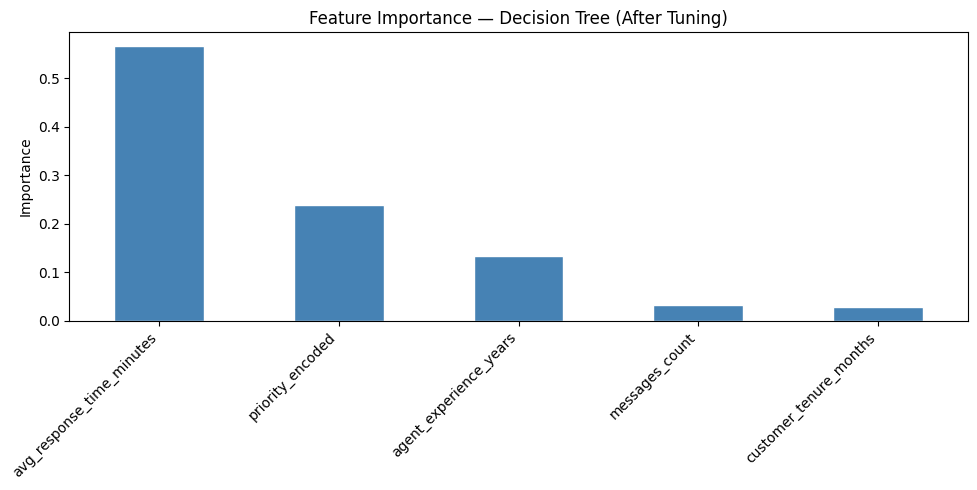

In [ ]:
# ============================================================
# Hyperparameter Tuning — Decision Tree Classifier
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# ── กำหนด Parameter Grid ─────────────────────────────────────
param_grid = {
    'max_depth':        [3, 5, 8, 10, 15],
    'min_samples_split':[2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion':        ['gini', 'entropy'],
}

# ── Grid Search with Cross-Validation (5-Fold) ───────────────
print("⏳ กำลังรัน GridSearchCV... (อาจใช้เวลา 2-5 นาที)")

grid_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid = param_grid,
    cv         = 5,           # 5-Fold Cross Validation
    scoring    = 'f1',        # optimize F1 ของ Class 1
    n_jobs     = -1,          # ใช้ทุก CPU core
    verbose    = 1
)

grid_search.fit(X_train_c, y_train_c)

# ── Best Parameters ───────────────────────────────────────────
print("\n✅ Best Parameters:")
print(grid_search.best_params_)
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

# ── Train โมเดลด้วย Best Parameters ─────────────────────────
best_clf = grid_search.best_estimator_
y_pred_best = best_clf.predict(X_test_c)

# ── เปรียบเทียบ Before vs After Tuning ───────────────────────
print("\n" + "=" * 60)
print("📊 เปรียบเทียบ Before vs After Hyperparameter Tuning")
print("=" * 60)

# Before (depth=8, default params)
clf_before = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
clf_before.fit(X_train_c, y_train_c)
y_pred_before = clf_before.predict(X_test_c)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
before  = [accuracy_score(y_test_c, y_pred_before),
           precision_score(y_test_c, y_pred_before),
           recall_score(y_test_c, y_pred_before),
           f1_score(y_test_c, y_pred_before)]
after   = [accuracy_score(y_test_c, y_pred_best),
           precision_score(y_test_c, y_pred_best),
           recall_score(y_test_c, y_pred_best),
           f1_score(y_test_c, y_pred_best)]

print(f"{'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 45)
for m, b, a in zip(metrics, before, after):
    change = a - b
    arrow  = "▲" if change > 0 else "▼" if change < 0 else "─"
    print(f"{m:<12} {b:>10.4f} {a:>10.4f} {arrow} {abs(change):.4f}")

# ── Classification Report (After Tuning) ─────────────────────
print("\nClassification Report (After Tuning):")
print(classification_report(y_test_c, y_pred_best,
      target_names=['Not Escalated (0)', 'Escalated (1)']))

print("Confusion Matrix (After Tuning):")
print(confusion_matrix(y_test_c, y_pred_best))

# ── Plot: เปรียบเทียบ Before vs After ────────────────────────
x      = np.arange(len(metrics))
width  = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, before, width, label='Before Tuning (depth=8)', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, after,  width, label='After Tuning (Best Params)', color='salmon',   alpha=0.8)

ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Decision Tree — Before vs After Hyperparameter Tuning')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Plot: Feature Importance (After Tuning) ───────────────────
fi_best = pd.Series(best_clf.feature_importances_,
                    index=feature_cols_clf).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
fi_best[fi_best > 0].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree (After Tuning)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

📋 Parameter Grid ที่ทดสอบ:
  max_depth: [3, 5, 8, 10, 15]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 5, 10]
  criterion: ['gini', 'entropy']

  จำนวน combinations ทั้งหมด: 160 combinations × 5 folds

⏳ กำลังรัน GridSearchCV (5-Fold, scoring=f1)...
Fitting 5 folds for each of 160 candidates, totalling 800 fits

✅ Best Parameters:
  criterion: gini
  max_depth: 5
  min_samples_leaf: 10
  min_samples_split: 2

  Best CV F1-score: 0.5430

📊 Top 10 Parameter Combinations:
   max_depth  min_samples_split  min_samples_leaf criterion  mean_F1  std_F1
0          5                 20                10      gini   0.5430  0.0147
1          5                 10                10      gini   0.5430  0.0147
2          5                  5                10      gini   0.5430  0.0147
3          5                  2                10      gini   0.5430  0.0147
4          5                 20                 5      gini   0.5428  0.0149
5          5                 10               

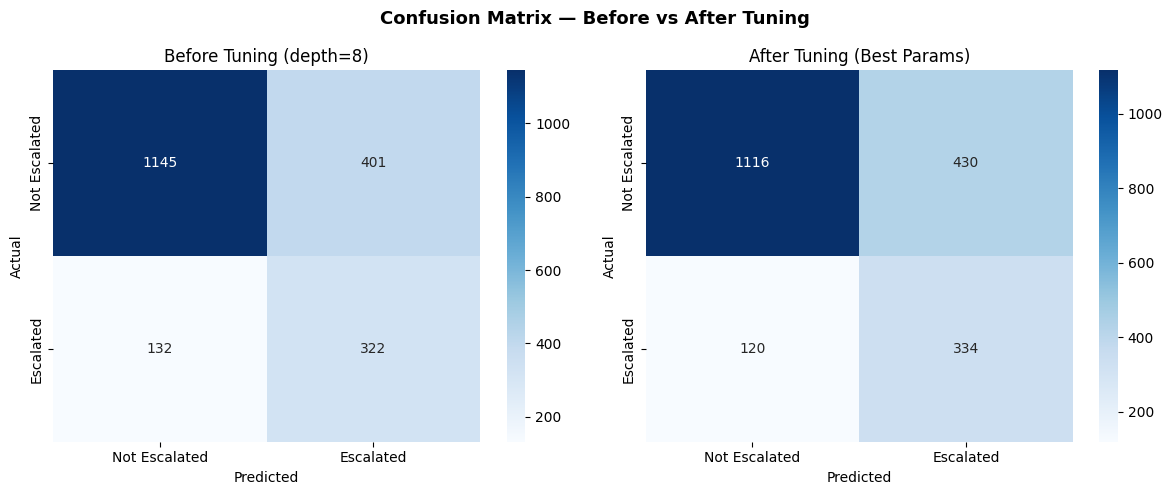

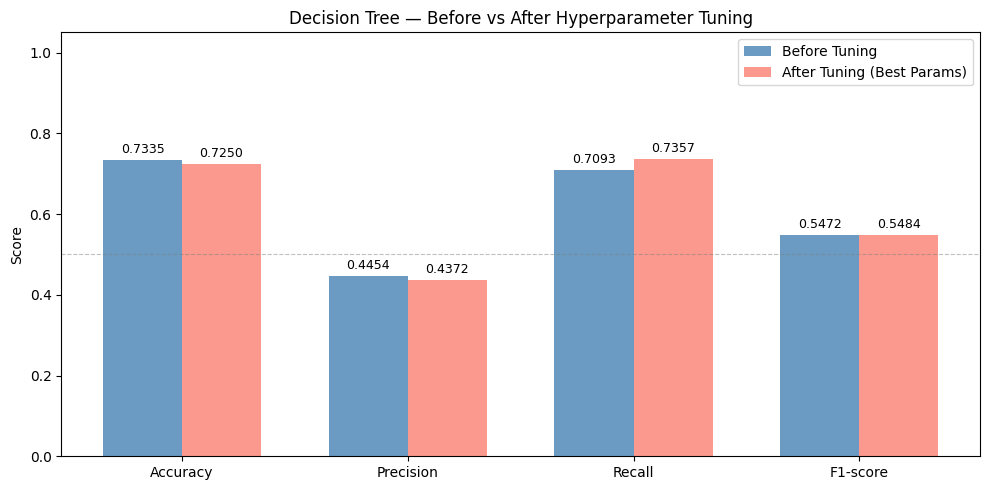

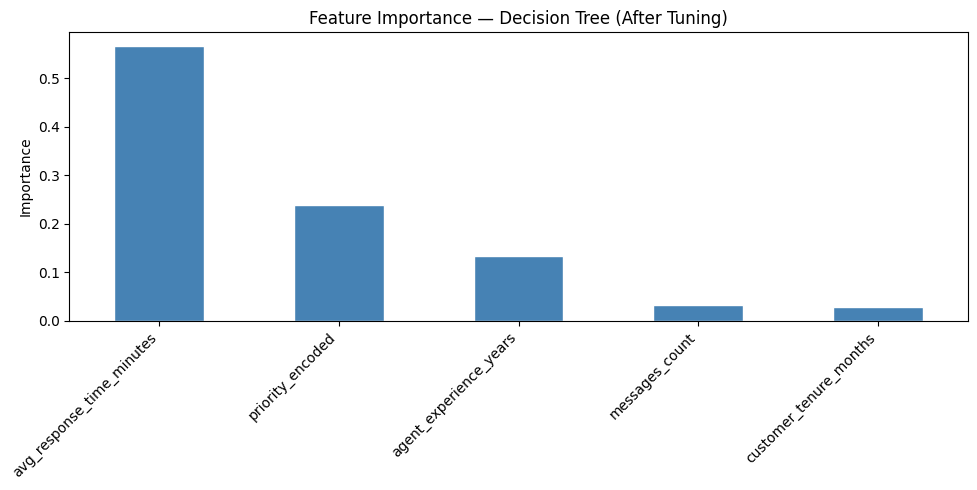


📊 สรุปผล Hyperparameter Tuning
Best Parameters : {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV F1      : 0.5430
Test Accuracy   : 0.7250
Test Precision  : 0.4372
Test Recall     : 0.7357
Test F1-score   : 0.5484


In [ ]:
# ============================================================
# Hyperparameter Tuning — Decision Tree Classifier
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# ── กำหนด Parameter Grid ─────────────────────────────────────
param_grid = {
    'max_depth':         [3, 5, 8, 10, 15],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 5, 10],
    'criterion':         ['gini', 'entropy'],
}

print("📋 Parameter Grid ที่ทดสอบ:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")
print(f"\n  จำนวน combinations ทั้งหมด: "
      f"{len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['criterion'])} combinations × 5 folds")

# ── Grid Search with 5-Fold Cross Validation ─────────────────
print("\n⏳ กำลังรัน GridSearchCV (5-Fold, scoring=f1)...")

grid_search = GridSearchCV(
    estimator  = DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

grid_search.fit(X_train_c, y_train_c)

# ── Best Parameters ───────────────────────────────────────────
print("\n✅ Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n  Best CV F1-score: {grid_search.best_score_:.4f}")

# ── ผลลัพธ์ทุก combination (Top 10) ──────────────────────────
results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (results_df[['param_max_depth', 'param_min_samples_split',
                      'param_min_samples_leaf', 'param_criterion',
                      'mean_test_score', 'std_test_score']]
         .sort_values('mean_test_score', ascending=False)
         .head(10)
         .reset_index(drop=True))
top10.columns = ['max_depth', 'min_samples_split', 'min_samples_leaf',
                 'criterion', 'mean_F1', 'std_F1']
top10['mean_F1'] = top10['mean_F1'].round(4)
top10['std_F1']  = top10['std_F1'].round(4)

print("\n📊 Top 10 Parameter Combinations:")
print(top10.to_string(index=True))

# ── Train โมเดล Before (depth=8, default) ────────────────────
clf_before = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42)
clf_before.fit(X_train_c, y_train_c)
y_pred_before = clf_before.predict(X_test_c)

# ── Train โมเดล After (Best Params) ──────────────────────────
best_clf = grid_search.best_estimator_
y_pred_after = best_clf.predict(X_test_c)

# ── เปรียบเทียบ Before vs After ──────────────────────────────
print("\n" + "=" * 60)
print("📊 Before vs After Hyperparameter Tuning")
print("=" * 60)

metrics_name = ['Accuracy', 'Precision', 'Recall', 'F1-score']
scores_before = [
    accuracy_score(y_test_c, y_pred_before),
    precision_score(y_test_c, y_pred_before),
    recall_score(y_test_c, y_pred_before),
    f1_score(y_test_c, y_pred_before),
]
scores_after = [
    accuracy_score(y_test_c, y_pred_after),
    precision_score(y_test_c, y_pred_after),
    recall_score(y_test_c, y_pred_after),
    f1_score(y_test_c, y_pred_after),
]

print(f"\n{'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 46)
for m, b, a in zip(metrics_name, scores_before, scores_after):
    change = a - b
    arrow  = "▲" if change > 0.0001 else ("▼" if change < -0.0001 else "─")
    print(f"{m:<12} {b:>10.4f} {a:>10.4f}   {arrow} {abs(change):.4f}")

# ── Classification Report ─────────────────────────────────────
print("\nClassification Report (After Tuning):")
print(classification_report(y_test_c, y_pred_after,
      target_names=['Not Escalated (0)', 'Escalated (1)']))

print("Confusion Matrix (After Tuning):")
cm = confusion_matrix(y_test_c, y_pred_after)
print(cm)

# ── Plot: Confusion Matrix ────────────────────────────────────
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_before, y_pred_after],
    ['Before Tuning (depth=8)', f'After Tuning (Best Params)']
):
    cm_plot = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Escalated', 'Escalated'],
                yticklabels=['Not Escalated', 'Escalated'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Before vs After Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot: Before vs After Bar Chart ──────────────────────────
x     = np.arange(len(metrics_name))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, scores_before, width,
               label='Before Tuning', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, scores_after,  width,
               label='After Tuning (Best Params)', color='salmon', alpha=0.8)

ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(metrics_name)
ax.set_ylabel('Score')
ax.set_title('Decision Tree — Before vs After Hyperparameter Tuning')
ax.legend()
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Plot: Feature Importance (After Tuning) ───────────────────
fi_best = pd.Series(best_clf.feature_importances_,
                    index=feature_cols_clf).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_best[fi_best > 0].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Decision Tree (After Tuning)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── สรุปผล ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📊 สรุปผล Hyperparameter Tuning")
print("=" * 60)
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1      : {grid_search.best_score_:.4f}")
print(f"Test Accuracy   : {accuracy_score(y_test_c, y_pred_after):.4f}")
print(f"Test Precision  : {precision_score(y_test_c, y_pred_after):.4f}")
print(f"Test Recall     : {recall_score(y_test_c, y_pred_after):.4f}")
print(f"Test F1-score   : {f1_score(y_test_c, y_pred_after):.4f}")
print("=" * 60)

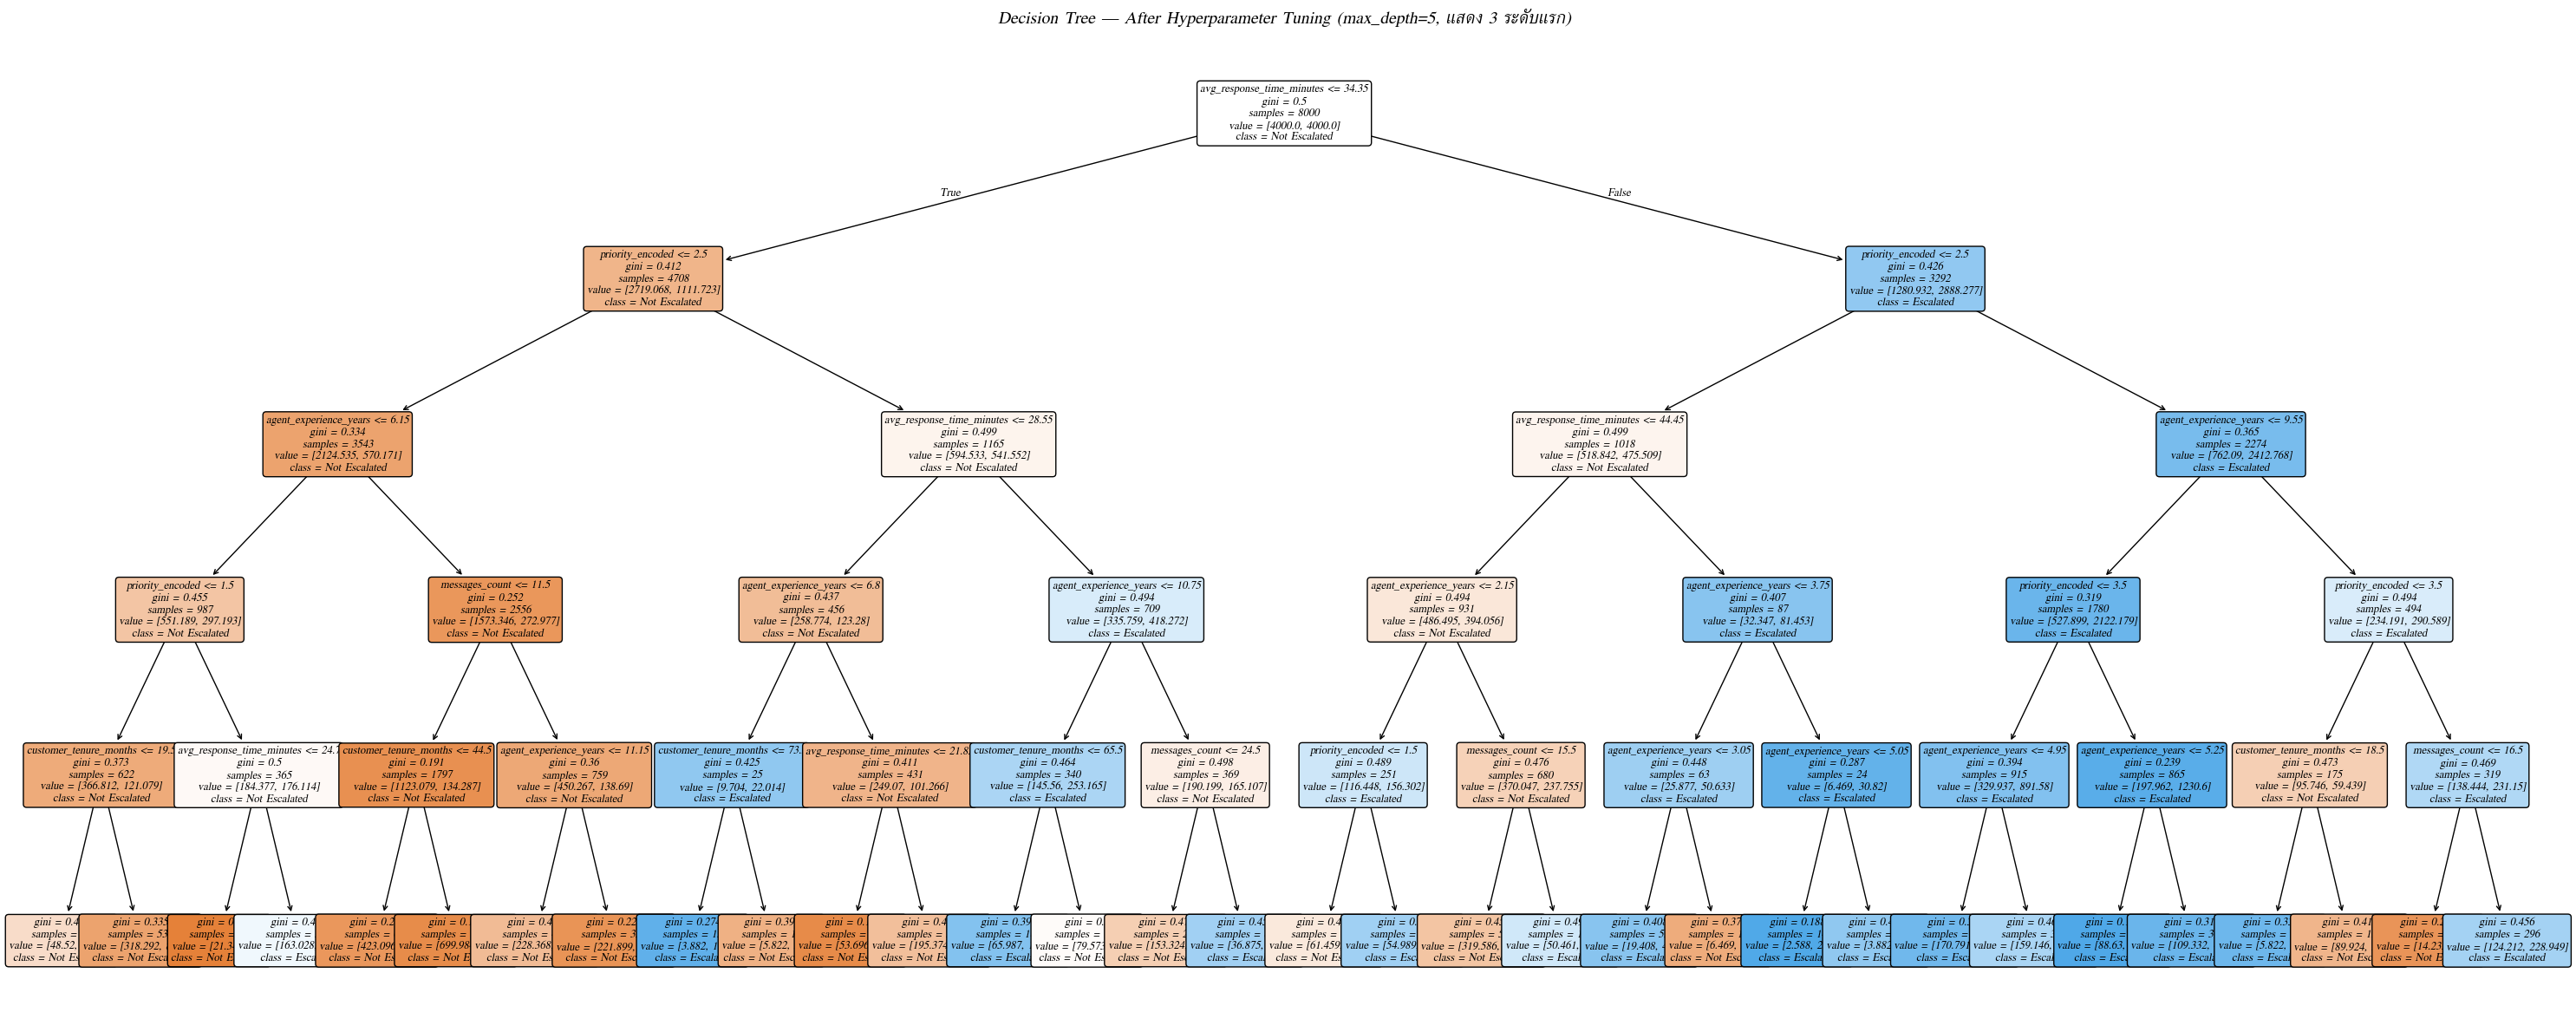

✅ บันทึกภาพ Decision Tree เป็น decision_tree_after_tuning.png แล้ว


In [ ]:
# ── Plot: Decision Tree Visualization (After Tuning) ──────────
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 12))
plot_tree(
    best_clf,
    feature_names = feature_cols_clf,
    class_names   = ['Not Escalated', 'Escalated'],
    filled        = True,
    rounded       = True,
    fontsize      = 9,
    max_depth     = 5          # แสดงแค่ 3 ระดับแรก ไม่งั้นภาพแน่นมาก
)
plt.title('Decision Tree — After Hyperparameter Tuning (max_depth=5, แสดง 3 ระดับแรก)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_after_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกภาพ Decision Tree เป็น decision_tree_after_tuning.png แล้ว")

#Gradiant boosting reg

📋 Parameter Grid ที่ทดสอบ:
  n_estimators: [50, 100, 200]
  max_depth: [3, 5, 8]
  learning_rate: [0.05, 0.1, 0.2]
  min_samples_split: [2, 5, 10]

  จำนวน combinations ทั้งหมด: 81 combinations × 5 folds

⏳ กำลังรัน GridSearchCV (5-Fold, scoring=neg_MAE)...
   อาจใช้เวลา 5-15 นาที...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

✅ Best Parameters:
  learning_rate: 0.05
  max_depth: 3
  min_samples_split: 5
  n_estimators: 200

  Best CV MAE: 5.9181 ชม.

📊 Top 10 Parameter Combinations:
   n_estimators  max_depth  learning_rate  min_samples_split  mean_MAE  std_MAE
0           200          3           0.05                  5    5.9181   0.1215
1           200          3           0.05                 10    5.9190   0.1201
2           200          3           0.05                  2    5.9208   0.1207
3           200          3           0.10                  2    5.9266   0.1163
4           100          3           0.10                  5    5.9283   0.1081
5           

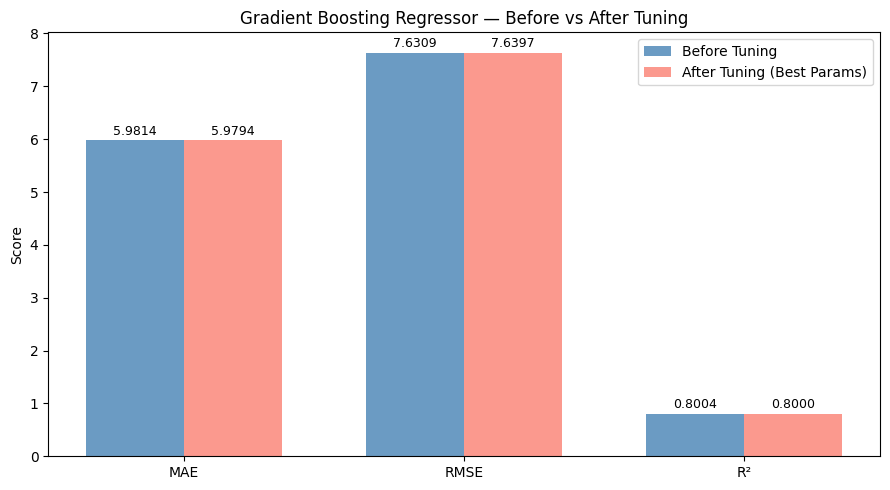

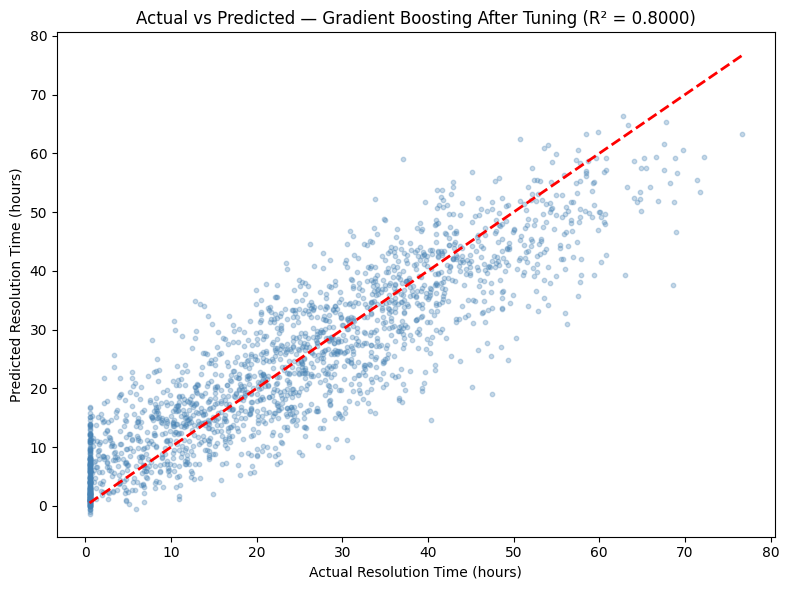

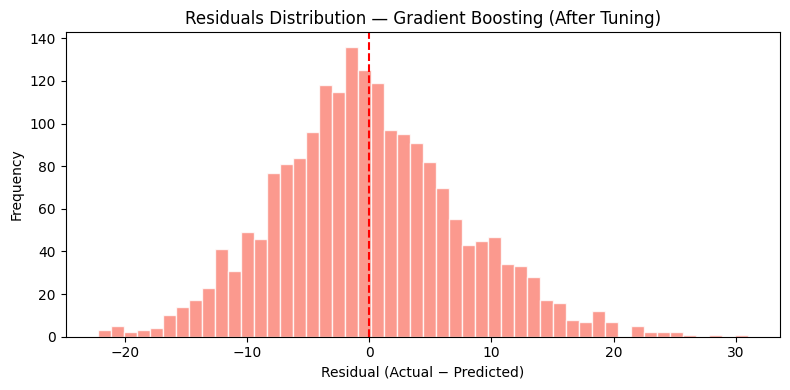

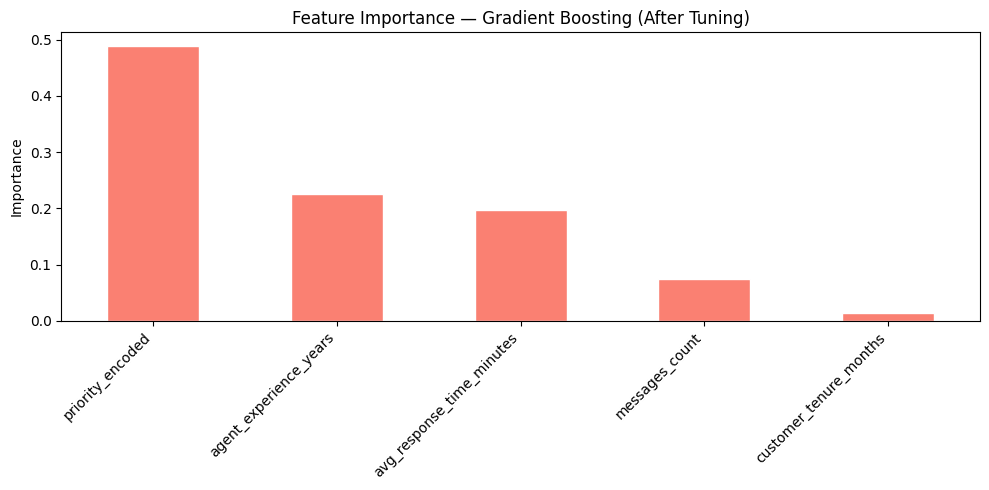


📊 สรุปผล Hyperparameter Tuning — Gradient Boosting
Best Parameters : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 200}
Best CV MAE     : 5.9181 ชม.
Test MAE        : 5.9794 ชม.
Test RMSE       : 7.6397 ชม.
Test R²         : 0.8000


In [ ]:
# ============================================================
# Hyperparameter Tuning — Gradient Boosting Regressor
# ============================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── กำหนด Parameter Grid ─────────────────────────────────────
param_grid_reg = {
    'n_estimators':   [50, 100, 200],
    'max_depth':      [3, 5, 8],
    'learning_rate':  [0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10],
}

print("📋 Parameter Grid ที่ทดสอบ:")
for param, values in param_grid_reg.items():
    print(f"  {param}: {values}")

total = 1
for v in param_grid_reg.values():
    total *= len(v)
print(f"\n  จำนวน combinations ทั้งหมด: {total} combinations × 5 folds")

# ── Grid Search with 5-Fold Cross Validation ─────────────────
print("\n⏳ กำลังรัน GridSearchCV (5-Fold, scoring=neg_MAE)...")
print("   อาจใช้เวลา 5-15 นาที...")

grid_search_reg = GridSearchCV(
    estimator  = GradientBoostingRegressor(random_state=42),
    param_grid = param_grid_reg,
    cv         = 5,
    scoring    = 'neg_mean_absolute_error',  # MAE ยิ่งน้อยยิ่งดี
    n_jobs     = -1,
    verbose    = 1
)

grid_search_reg.fit(X_train_r, y_train_r)

# ── Best Parameters ───────────────────────────────────────────
print("\n✅ Best Parameters:")
for param, value in grid_search_reg.best_params_.items():
    print(f"  {param}: {value}")
print(f"\n  Best CV MAE: {-grid_search_reg.best_score_:.4f} ชม.")

# ── Top 10 Combinations ───────────────────────────────────────
results_reg = pd.DataFrame(grid_search_reg.cv_results_)
top10_reg = (results_reg[['param_n_estimators', 'param_max_depth',
                           'param_learning_rate', 'param_min_samples_split',
                           'mean_test_score', 'std_test_score']]
             .sort_values('mean_test_score', ascending=False)
             .head(10)
             .reset_index(drop=True))
top10_reg.columns = ['n_estimators', 'max_depth', 'learning_rate',
                     'min_samples_split', 'mean_MAE', 'std_MAE']
top10_reg['mean_MAE'] = (-top10_reg['mean_MAE']).round(4)
top10_reg['std_MAE']  = top10_reg['std_MAE'].round(4)

print("\n📊 Top 10 Parameter Combinations:")
print(top10_reg.to_string(index=True))

# ── Train โมเดล Before (default n=100) ───────────────────────
reg_before = GradientBoostingRegressor(n_estimators=100, random_state=42)
reg_before.fit(X_train_r, y_train_r)
y_pred_before_r = reg_before.predict(X_test_r)

# ── Train โมเดล After (Best Params) ──────────────────────────
best_reg = grid_search_reg.best_estimator_
y_pred_after_r = best_reg.predict(X_test_r)

# ── เปรียบเทียบ Before vs After ──────────────────────────────
mae_b  = mean_absolute_error(y_test_r, y_pred_before_r)
rmse_b = np.sqrt(mean_squared_error(y_test_r, y_pred_before_r))
r2_b   = r2_score(y_test_r, y_pred_before_r)

mae_a  = mean_absolute_error(y_test_r, y_pred_after_r)
rmse_a = np.sqrt(mean_squared_error(y_test_r, y_pred_after_r))
r2_a   = r2_score(y_test_r, y_pred_after_r)

print("\n" + "=" * 60)
print("📊 Before vs After Hyperparameter Tuning (Regression)")
print("=" * 60)
print(f"{'Metric':<8} {'Before':>10} {'After':>10} {'Change':>12}")
print("-" * 44)

for metric, b, a, better in [
    ('MAE',  mae_b,  mae_a,  'low'),
    ('RMSE', rmse_b, rmse_a, 'low'),
    ('R²',   r2_b,   r2_a,   'high'),
]:
    change = a - b
    if better == 'low':
        arrow = "▼ ดีขึ้น" if change < -0.0001 else ("▲ แย่ลง" if change > 0.0001 else "─")
    else:
        arrow = "▲ ดีขึ้น" if change > 0.0001 else ("▼ แย่ลง" if change < -0.0001 else "─")
    print(f"{metric:<8} {b:>10.4f} {a:>10.4f}   {arrow} {abs(change):.4f}")

# ── Plot: Before vs After Bar Chart ──────────────────────────
metrics_reg = ['MAE', 'RMSE', 'R²']
before_vals = [mae_b, rmse_b, r2_b]
after_vals  = [mae_a, rmse_a, r2_a]

x     = np.arange(len(metrics_reg))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, before_vals, width,
               label='Before Tuning', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, after_vals,  width,
               label='After Tuning (Best Params)', color='salmon', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_reg)
ax.set_ylabel('Score')
ax.set_title('Gradient Boosting Regressor — Before vs After Tuning')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ── Plot: Actual vs Predicted (After Tuning) ─────────────────
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_after_r, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()], 'r--', linewidth=2)
plt.xlabel('Actual Resolution Time (hours)')
plt.ylabel('Predicted Resolution Time (hours)')
plt.title(f'Actual vs Predicted — Gradient Boosting After Tuning (R² = {r2_a:.4f})')
plt.tight_layout()
plt.show()

# ── Plot: Residuals (After Tuning) ───────────────────────────
residuals_a = y_test_r - y_pred_after_r
plt.figure(figsize=(8, 4))
plt.hist(residuals_a, bins=50, color='salmon', edgecolor='white', alpha=0.8)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution — Gradient Boosting (After Tuning)')
plt.xlabel('Residual (Actual − Predicted)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# ── Feature Importance (After Tuning) ────────────────────────
fi_reg_best = pd.Series(best_reg.feature_importances_,
                        index=feature_cols_reg).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_reg_best[fi_reg_best > 0.01].plot(kind='bar', color='salmon', edgecolor='white')
plt.title('Feature Importance — Gradient Boosting (After Tuning)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ── สรุปผล ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📊 สรุปผล Hyperparameter Tuning — Gradient Boosting")
print("=" * 60)
print(f"Best Parameters : {grid_search_reg.best_params_}")
print(f"Best CV MAE     : {-grid_search_reg.best_score_:.4f} ชม.")
print(f"Test MAE        : {mae_a:.4f} ชม.")
print(f"Test RMSE       : {rmse_a:.4f} ชม.")
print(f"Test R²         : {r2_a:.4f}")
print("=" * 60)

In [ ]:
!apt-get install -y fonts-thai-tlwg 2>/dev/null
!fc-cache -fv 2>/dev/null

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import subprocess

# ค้นหา font ไทยที่มีในระบบ
result = subprocess.run(['find', '/usr/share/fonts', '-name', '*.ttf'],
                       capture_output=True, text=True)
all_fonts = result.stdout.strip().split('\n')

# กรองเอาเฉพาะ font ไทย
thai_keywords = ['Sarabun', 'Loma', 'Garuda', 'Norasi', 'Kinnari', 'Purisa', 'tlwg', 'Noto']
thai_fonts = [f for f in all_fonts if any(k in f for k in thai_keywords)]

print("Font ไทยที่เจอ:")
for f in thai_fonts:
    print(f)

# ใช้ font แรกที่เจอ
if thai_fonts:
    font_path = thai_fonts[0]
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = prop.get_name()
    plt.rcParams['axes.unicode_minus'] = False
    print(f"\n✅ ใช้ font: {font_path}")
else:
    print("❌ ไม่เจอ font ไทย")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

PART 1: Feature Direction — Decision Tree Classifier

📊 Mean ของแต่ละ Feature แยกตาม Class:
Feature                          Class 0 (ปกติ)  Class 1 (บานปลาย)   ทิศทาง
----------------------------------------------------------------------------
priority_encoded                          2.056              3.042      ▲ บวก
avg_response_time_minutes                30.309             39.218      ▲ บวก
messages_count                           12.015             18.707      ▲ บวก
agent_experience_years                    8.146              5.678       ▼ ลบ
customer_tenure_months                   62.613             57.676       ▼ ลบ
ticket_type_Account                       0.173              0.174     ─ กลาง
ticket_type_Billing                       0.197              0.216      ▲ บวก
ticket_type_Other                         0.167              0.183      ▲ บวก
ticket_type_Product                       0.221              0.222     ─ กลาง
ticket_type_Technical                     0.242      

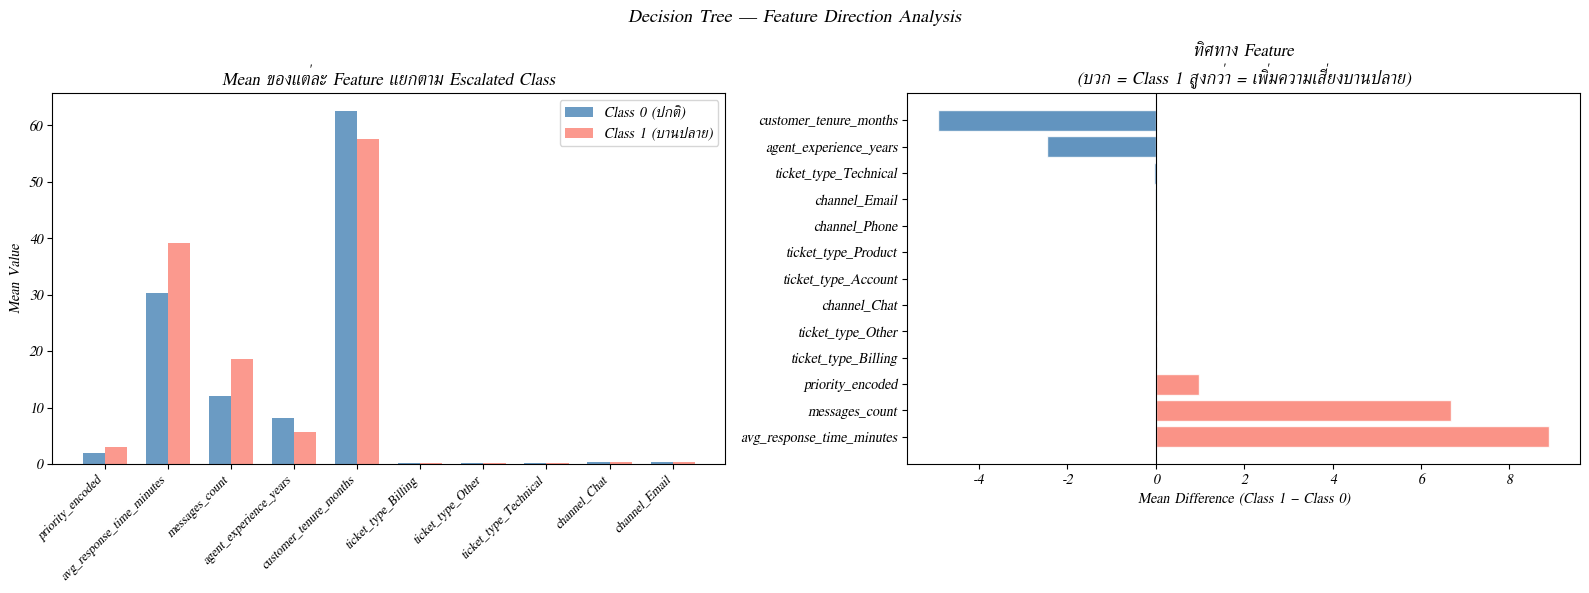


PART 2: Feature Direction — Gradient Boosting Regressor

📊 Correlation กับ resolution_time_hours:
Feature                         Correlation     ทิศทาง
-------------------------------------------------------
agent_experience_years              -0.4840       ▼ ลบ
customer_tenure_months              -0.0861       ▼ ลบ
channel_Phone                       -0.0219       ▼ ลบ
ticket_type_Other                   -0.0085     ─ กลาง
ticket_type_Billing                 -0.0037     ─ กลาง
ticket_type_Technical               -0.0013     ─ กลาง
channel_Email                       -0.0006     ─ กลาง
ticket_type_Account                  0.0028     ─ กลาง
ticket_type_Product                  0.0099     ─ กลาง
channel_Chat                         0.0219      ▲ บวก
messages_count                       0.6664      ▲ บวก
avg_response_time_minutes            0.7266      ▲ บวก
priority_encoded                     0.7343      ▲ บวก


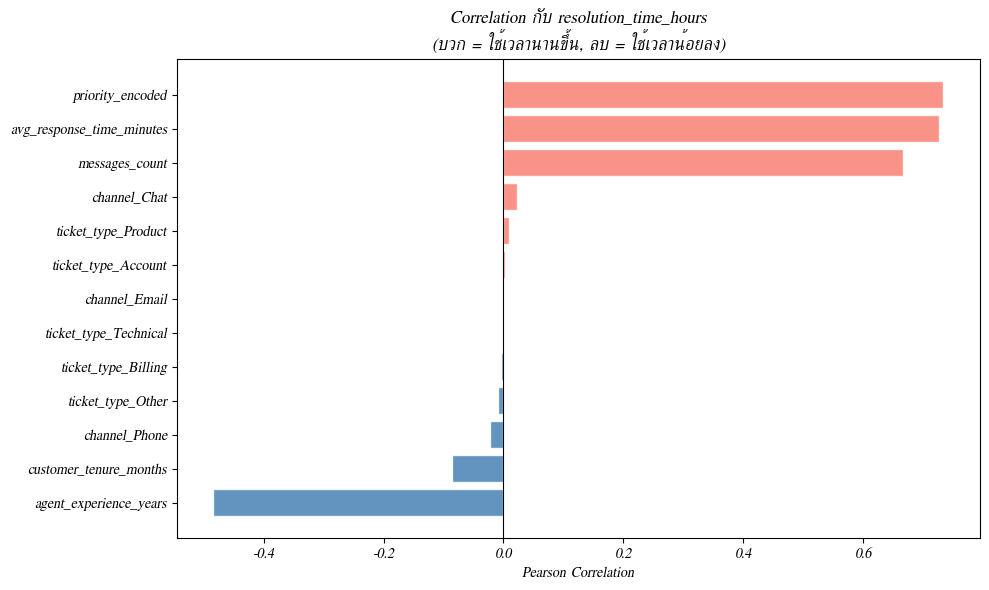


⏳ กำลังสร้าง Partial Dependence Plot...


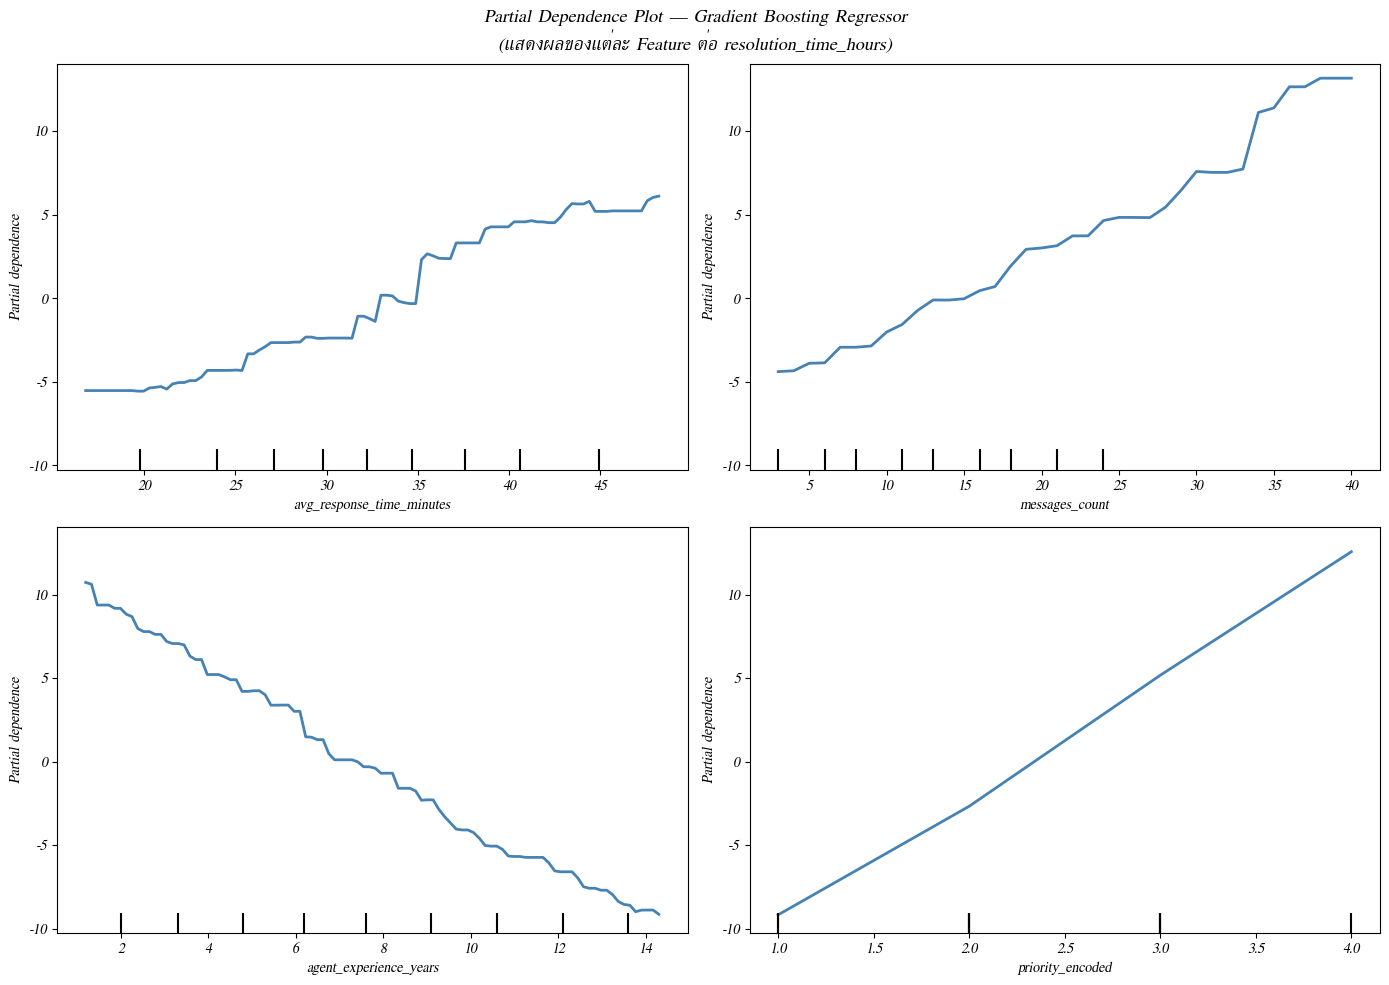


📊 สรุปทิศทาง Feature ทั้งสองโมเดล

[Classification — escalated]
  ▲ เพิ่มความเสี่ยงบานปลาย :
     priority_encoded               (diff = +0.986)
     avg_response_time_minutes      (diff = +8.909)
     messages_count                 (diff = +6.692)
     ticket_type_Billing            (diff = +0.019)
     ticket_type_Other              (diff = +0.016)
     channel_Chat                   (diff = +0.016)
  ▼ ลดความเสี่ยงบานปลาย :
     agent_experience_years         (diff = -2.467)
     customer_tenure_months         (diff = -4.937)
     ticket_type_Technical          (diff = -0.037)
     channel_Email                  (diff = -0.013)

[Regression — resolution_time_hours]
  ▲ เพิ่มระยะเวลาปิดเคส :
     channel_Chat                   (r = +0.0219)
     messages_count                 (r = +0.6664)
     avg_response_time_minutes      (r = +0.7266)
     priority_encoded               (r = +0.7343)
  ▼ ลดระยะเวลาปิดเคส :
     agent_experience_years         (r = -0.4840)
     customer_tenure_mo

In [ ]:
# ============================================================
# Feature Direction Analysis
# Classification: Permutation Importance + Mean by Class
# Regression: Gradient Boosting Partial Dependence
# ============================================================

from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================================
# PART 1: Decision Tree Classifier
# — ทิศทาง Feature โดยดูจาก Mean ของแต่ละ Class
# ============================================================
print("=" * 60)
print("PART 1: Feature Direction — Decision Tree Classifier")
print("=" * 60)

# รวม X_test กับ y_test เพื่อดู mean แต่ละ class
df_analysis = X_test_c.copy()
df_analysis['escalated'] = y_test_c.values

print("\n📊 Mean ของแต่ละ Feature แยกตาม Class:")
print(f"{'Feature':<30} {'Class 0 (ปกติ)':>16} {'Class 1 (บานปลาย)':>18} {'ทิศทาง':>8}")
print("-" * 76)

directions = []
for col in feature_cols_clf:
    mean_0 = df_analysis[df_analysis['escalated'] == 0][col].mean()
    mean_1 = df_analysis[df_analysis['escalated'] == 1][col].mean()
    diff   = mean_1 - mean_0
    arrow  = "▲ บวก" if diff > 0.01 else ("▼ ลบ" if diff < -0.01 else "─ กลาง")
    directions.append({'Feature': col, 'Class_0': mean_0, 'Class_1': mean_1,
                       'Diff': diff, 'Direction': arrow})
    print(f"{col:<30} {mean_0:>16.3f} {mean_1:>18.3f} {arrow:>10}")

dir_df = pd.DataFrame(directions).sort_values('Diff', ascending=False)

# ── Plot: Feature Direction (Classification) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Mean by Class grouped bar
top_features = [d for d in directions if abs(d['Diff']) > 0.01]
feat_names   = [d['Feature'] for d in top_features]
means_0      = [d['Class_0'] for d in top_features]
means_1      = [d['Class_1'] for d in top_features]

x     = np.arange(len(feat_names))
width = 0.35
axes[0].bar(x - width/2, means_0, width, label='Class 0 (ปกติ)',     color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, means_1, width, label='Class 1 (บานปลาย)', color='salmon',    alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(feat_names, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Mean ของแต่ละ Feature แยกตาม Escalated Class')
axes[0].set_ylabel('Mean Value')
axes[0].legend()

# Right: Diff bar (บวก/ลบ)
colors = ['salmon' if d > 0 else 'steelblue' for d in dir_df['Diff']]
axes[1].barh(dir_df['Feature'], dir_df['Diff'], color=colors, edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('ทิศทาง Feature\n(บวก = Class 1 สูงกว่า = เพิ่มความเสี่ยงบานปลาย)')
axes[1].set_xlabel('Mean Difference (Class 1 − Class 0)')

plt.suptitle('Decision Tree — Feature Direction Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# PART 2: Gradient Boosting Regressor
# — ดูทิศทางจาก Partial Dependence Plot + Correlation
# ============================================================
print("\n" + "=" * 60)
print("PART 2: Feature Direction — Gradient Boosting Regressor")
print("=" * 60)

# ── Correlation ของ Feature กับ Target ───────────────────────
corr_reg = pd.DataFrame(X_train_r, columns=feature_cols_reg).copy()
corr_reg['resolution_time_hours'] = y_train_r.values
corr_vals = corr_reg.corr()['resolution_time_hours'].drop('resolution_time_hours').sort_values()

print("\n📊 Correlation กับ resolution_time_hours:")
print(f"{'Feature':<30} {'Correlation':>12} {'ทิศทาง':>10}")
print("-" * 55)
for feat, val in corr_vals.items():
    arrow = "▲ บวก" if val > 0.01 else ("▼ ลบ" if val < -0.01 else "─ กลาง")
    print(f"{feat:<30} {val:>12.4f} {arrow:>10}")

# ── Plot: Correlation bar ─────────────────────────────────────
plt.figure(figsize=(10, 6))
colors_corr = ['salmon' if v > 0 else 'steelblue' for v in corr_vals.values]
plt.barh(corr_vals.index, corr_vals.values, color=colors_corr, edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlation กับ resolution_time_hours\n(บวก = ใช้เวลานานขึ้น, ลบ = ใช้เวลาน้อยลง)')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

# ── Partial Dependence Plot (Top 4 numeric features) ─────────
print("\n⏳ กำลังสร้าง Partial Dependence Plot...")

top4_features = ['avg_response_time_minutes', 'messages_count',
                 'agent_experience_years', 'priority_encoded']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    best_reg,
    X_train_r,
    features       = top4_features,
    feature_names  = feature_cols_reg,
    ax             = axes.flatten(),
    line_kw        = {"color": "steelblue", "linewidth": 2}
)
plt.suptitle('Partial Dependence Plot — Gradient Boosting Regressor\n'
             '(แสดงผลของแต่ละ Feature ต่อ resolution_time_hours)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── สรุปทิศทาง ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("📊 สรุปทิศทาง Feature ทั้งสองโมเดล")
print("=" * 60)
print("\n[Classification — escalated]")
print("  ▲ เพิ่มความเสี่ยงบานปลาย :")
for d in directions:
    if '▲' in d['Direction'] and abs(d['Diff']) > 0.01:
        print(f"     {d['Feature']:<30} (diff = +{d['Diff']:.3f})")
print("  ▼ ลดความเสี่ยงบานปลาย :")
for d in directions:
    if '▼' in d['Direction'] and abs(d['Diff']) > 0.01:
        print(f"     {d['Feature']:<30} (diff = {d['Diff']:.3f})")

print("\n[Regression — resolution_time_hours]")
print("  ▲ เพิ่มระยะเวลาปิดเคส :")
for feat, val in corr_vals.items():
    if val > 0.01:
        print(f"     {feat:<30} (r = +{val:.4f})")
print("  ▼ ลดระยะเวลาปิดเคส :")
for feat, val in corr_vals.items():
    if val < -0.01:
        print(f"     {feat:<30} (r = {val:.4f})")
print("=" * 60)

โมเดลเพิ่มเติม: Random Forest Classifier (escalated)

Accuracy  : 0.8065
Precision : 0.6293
Recall    : 0.3590
F1-score  : 0.4572

Classification Report:
                   precision    recall  f1-score   support

Not Escalated (0)       0.83      0.94      0.88      1546
    Escalated (1)       0.63      0.36      0.46       454

         accuracy                           0.81      2000
        macro avg       0.73      0.65      0.67      2000
     weighted avg       0.79      0.81      0.79      2000

Confusion Matrix:
[[1450   96]
 [ 291  163]]

📊 เปรียบเทียบ Decision Tree (After Tuning) vs Random Forest

Metric         Decision Tree   Random Forest
--------------------------------------------
Accuracy              0.7250          0.8065  ✅
Precision             0.4372          0.6293  ✅
Recall                0.7357          0.3590  ❌
F1-score              0.5484          0.4572  ❌


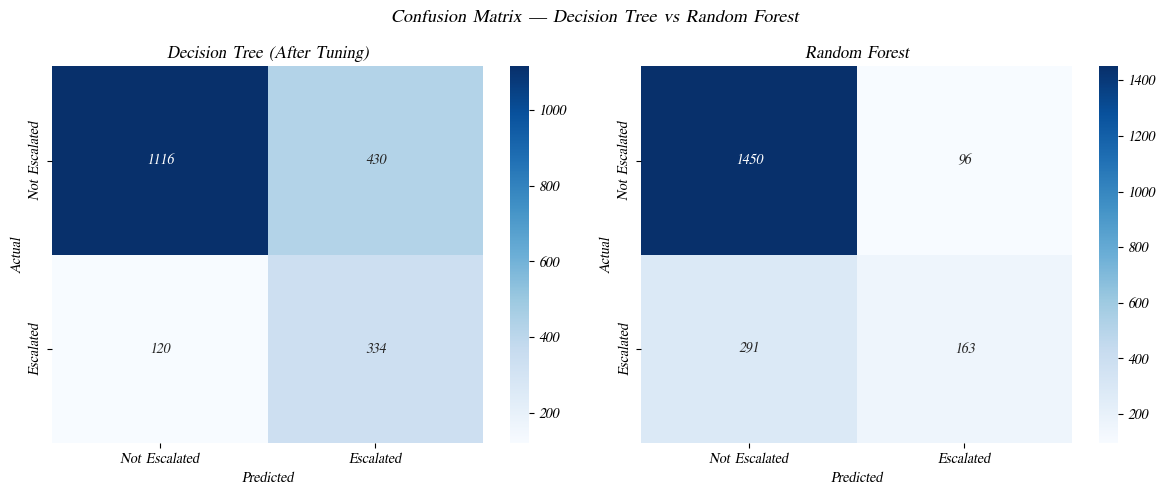

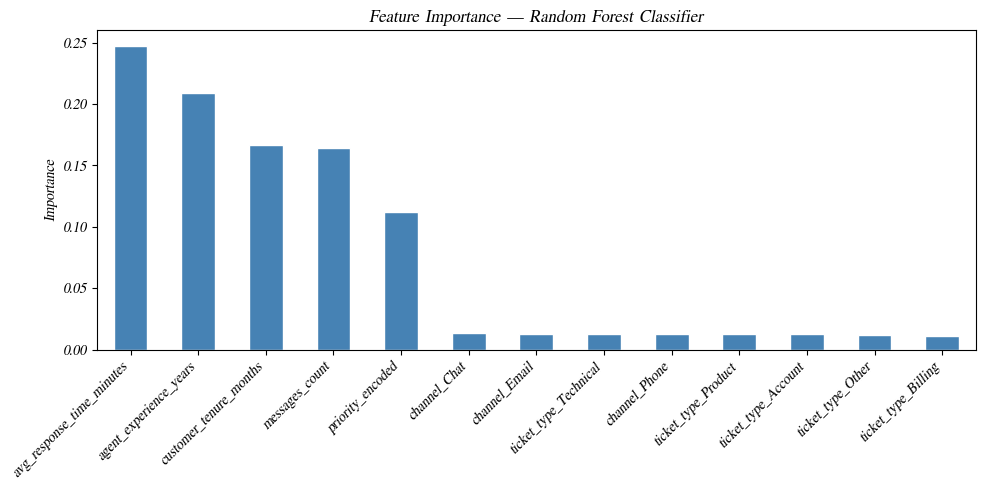

In [ ]:
# ============================================================
# โมเดลเพิ่มเติม: Random Forest Classifier (escalated)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
import seaborn as sns

print("=" * 60)
print("โมเดลเพิ่มเติม: Random Forest Classifier (escalated)")
print("=" * 60)

# ── Train โมเดล ───────────────────────────────────────────────
rf_clf = RandomForestClassifier(
    n_estimators  = 100,
    class_weight  = 'balanced',
    random_state  = 42,
    n_jobs        = -1
)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf = rf_clf.predict(X_test_c)

# ── ผลลัพธ์ ───────────────────────────────────────────────────
print(f"\nAccuracy  : {accuracy_score(y_test_c, y_pred_rf):.4f}")
print(f"Precision : {precision_score(y_test_c, y_pred_rf):.4f}")
print(f"Recall    : {recall_score(y_test_c, y_pred_rf):.4f}")
print(f"F1-score  : {f1_score(y_test_c, y_pred_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_rf,
      target_names=['Not Escalated (0)', 'Escalated (1)']))

print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_rf))

# ── เปรียบเทียบ Decision Tree vs Random Forest ────────────────
print("\n" + "=" * 60)
print("📊 เปรียบเทียบ Decision Tree (After Tuning) vs Random Forest")
print("=" * 60)

metrics_name = ['Accuracy', 'Precision', 'Recall', 'F1-score']
scores_dt = [0.7250, 0.4372, 0.7357, 0.5484]   # ค่าจาก Decision Tree After Tuning
scores_rf = [
    accuracy_score(y_test_c, y_pred_rf),
    precision_score(y_test_c, y_pred_rf),
    recall_score(y_test_c, y_pred_rf),
    f1_score(y_test_c, y_pred_rf),
]

print(f"\n{'Metric':<12} {'Decision Tree':>15} {'Random Forest':>15}")
print("-" * 44)
for m, dt, rf in zip(metrics_name, scores_dt, scores_rf):
    better = "✅" if rf > dt else ("❌" if rf < dt else "─")
    print(f"{m:<12} {dt:>15.4f} {rf:>15.4f}  {better}")

# ── Plot: Confusion Matrix เปรียบเทียบ ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_after, y_pred_rf],
    ['Decision Tree (After Tuning)', 'Random Forest']
):
    cm_plot = confusion_matrix(y_test_c, y_pred)
    sns.heatmap(cm_plot, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Escalated', 'Escalated'],
                yticklabels=['Not Escalated', 'Escalated'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix — Decision Tree vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Plot: Feature Importance ──────────────────────────────────
fi_rf = pd.Series(rf_clf.feature_importances_,
                  index=feature_cols_clf).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
fi_rf[fi_rf > 0].plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest Classifier')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Save Model

In [ ]:
# ── Mount Google Drive ────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── กำหนด Path ที่จะบันทึก ────────────────────────────────────
import os
save_dir = '/content/drive/MyDrive/CT663_2026/Project/'
os.makedirs(save_dir, exist_ok=True)

# ── บันทึกโมเดลลง Drive ──────────────────────────────────────
import joblib
joblib.dump(best_clf, f"{save_dir}/clf_model.pkl")   # Decision Tree After Tuning
joblib.dump(reg,      f"{save_dir}/reg_model.pkl")   # Gradient Boosting After Tuning
                                                      # ← แก้จาก reg_model เป็น reg

print("✅ บันทึกโมเดลลง Google Drive เรียบร้อย")
print(f"   📁 Path: {save_dir}")
print(f"   └── clf_model.pkl  ({type(best_clf).__name__})")
print(f"   └── reg_model.pkl  ({type(reg).__name__})")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ บันทึกโมเดลลง Google Drive เรียบร้อย
   📁 Path: /content/drive/MyDrive/CT663_2026/Project/
   └── clf_model.pkl  (DecisionTreeClassifier)
   └── reg_model.pkl  (GradientBoostingRegressor)


#Model deployment

In [4]:
# ============================================================
# Deployment — Jupyter Widget (รันใน Notebook เดิมได้เลย)
# ============================================================

import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# ── Feature Columns (เหมือนตอน Train) ───────────────────────
feature_cols = [
    'priority_encoded', 'avg_response_time_minutes', 'messages_count',
    'agent_experience_years', 'customer_tenure_months',
    'ticket_type_Account', 'ticket_type_Billing', 'ticket_type_Other',
    'ticket_type_Product', 'ticket_type_Technical',
    'channel_Chat', 'channel_Email', 'channel_Phone'
]

# ── Helper: สร้าง Feature Vector ─────────────────────────────
def build_features(priority, avg_response, messages,
                   agent_exp, tenure, ticket_type, channel):
    priority_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Critical': 4}
    row = {col: 0 for col in feature_cols}
    row['priority_encoded']           = priority_map[priority]
    row['avg_response_time_minutes']  = avg_response
    row['messages_count']             = messages
    row['agent_experience_years']     = agent_exp
    row['customer_tenure_months']     = tenure
    row[f'ticket_type_{ticket_type}'] = 1
    row[f'channel_{channel}']         = 1
    return pd.DataFrame([row])[feature_cols]

# ════════════════════════════════════════════════════════════
# WIDGETS: Input
# ════════════════════════════════════════════════════════════
style   = {'description_width': '200px'}
layout  = widgets.Layout(width='420px')

w_priority    = widgets.Dropdown(
    options=['Low', 'Medium', 'High', 'Critical'],
    value='Medium', description='Priority:', style=style, layout=layout)

w_ticket_type = widgets.Dropdown(
    options=['Account', 'Billing', 'Other', 'Product', 'Technical'],
    value='Technical', description='Ticket Type:', style=style, layout=layout)

w_channel     = widgets.Dropdown(
    options=['Chat', 'Email', 'Phone'],
    value='Chat', description='Channel:', style=style, layout=layout)

w_avg_response = widgets.IntSlider(
    value=15, min=1, max=60, step=1,
    description='Avg Response (นาที):', style=style, layout=layout)

w_messages    = widgets.IntSlider(
    value=10, min=3, max=80, step=1,
    description='Messages Count:', style=style, layout=layout)

w_agent_exp   = widgets.FloatSlider(
    value=3.0, min=0.5, max=15.0, step=0.5,
    description='Agent Experience (ปี):', style=style, layout=layout)

w_tenure      = widgets.IntSlider(
    value=36, min=1, max=119, step=1,
    description='Customer Tenure (เดือน):', style=style, layout=layout)

btn_predict   = widgets.Button(
    description='🔮 ทำนายผลลัพธ์',
    button_style='primary',
    layout=widgets.Layout(width='200px', height='40px'))

out = widgets.Output()

# ════════════════════════════════════════════════════════════
# PREDICT FUNCTION
# ════════════════════════════════════════════════════════════
def on_predict(b):
    with out:
        clear_output(wait=True)

        X_input = build_features(
            w_priority.value, w_avg_response.value, w_messages.value,
            w_agent_exp.value, w_tenure.value,
            w_ticket_type.value, w_channel.value
        )

        # ── ทำนาย ────────────────────────────────────────────
        esc_prob = best_clf.predict_proba(X_input)[0][1]   # Decision Tree
        esc_pred = best_clf.predict(X_input)[0]
        res_time = reg_model.predict(X_input)[0]           # Gradient Boosting

        # ── กำหนด Risk Level ──────────────────────────────────
        if esc_prob >= 0.7:
            risk_color = '#d32f2f'
            risk_label = '🔴 ความเสี่ยงสูงมาก — แนะนำให้หัวหน้างานเข้าแทรกแซงทันที'
        elif esc_prob >= 0.5:
            risk_color = '#f57c00'
            risk_label = '🟡 ความเสี่ยงปานกลาง — ควรติดตามเคสนี้อย่างใกล้ชิด'
        else:
            risk_color = '#388e3c'
            risk_label = '🟢 ความเสี่ยงต่ำ — ดำเนินการตามปกติ'

        # ════════════════════════════════════════════════════
        # PLOT
        # ════════════════════════════════════════════════════
        fig = plt.figure(figsize=(14, 9))
        fig.patch.set_facecolor('#f8f9fa')

        # ── Layout: 2 แถว 3 คอลัมน์ ──────────────────────────
        gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

        # ─────────────────────────────────────────────────────
        # [0,0] Result Card — Escalation
        # ─────────────────────────────────────────────────────
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.set_facecolor(risk_color)
        ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
        ax1.axis('off')
        verdict = 'ESCALATED' if esc_pred == 1 else 'NOT ESCALATED'
        ax1.text(0.5, 0.65, verdict, ha='center', va='center',
                 fontsize=16, fontweight='bold', color='white')
        ax1.text(0.5, 0.35, f'Probability: {esc_prob:.1%}',
                 ha='center', va='center', fontsize=12, color='white')
        ax1.set_title('🚨 Escalation Prediction', fontsize=11, fontweight='bold', pad=8)

        # ─────────────────────────────────────────────────────
        # [0,1] Result Card — Resolution Time
        # ─────────────────────────────────────────────────────
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.set_facecolor('#1565c0')
        ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
        ax2.axis('off')
        ax2.text(0.5, 0.65, f'{res_time:.1f}', ha='center', va='center',
                 fontsize=28, fontweight='bold', color='white')
        ax2.text(0.5, 0.30, 'ชั่วโมง', ha='center', va='center',
                 fontsize=13, color='white')
        ax2.set_title('⏱️ ระยะเวลาปิดเคส (คาดการณ์)', fontsize=11, fontweight='bold', pad=8)

        # ─────────────────────────────────────────────────────
        # [0,2] Gauge Bar — Risk Level
        # ─────────────────────────────────────────────────────
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.set_facecolor('#ffffff')
        ax3.set_xlim(0, 1); ax3.set_ylim(0, 1)
        ax3.axis('off')

        # วาด Gauge แบบ horizontal bar
        bar_y, bar_h = 0.45, 0.18
        # พื้นหลัง gradient (3 โซน)
        for x_start, color in [(0, '#c8e6c9'), (0.33, '#fff9c4'), (0.66, '#ffcdd2')]:
            ax3.add_patch(mpatches.FancyBboxPatch(
                (x_start + 0.01, bar_y), 0.31, bar_h,
                boxstyle='round,pad=0.01', facecolor=color, edgecolor='none'))
        # แถบ Probability
        ax3.add_patch(mpatches.FancyBboxPatch(
            (0.01, bar_y), esc_prob * 0.98, bar_h,
            boxstyle='round,pad=0.01', facecolor=risk_color, alpha=0.85, edgecolor='none'))
        # Label
        ax3.text(0.5, 0.78, f'{esc_prob:.1%}', ha='center', fontsize=14,
                 fontweight='bold', color=risk_color)
        ax3.text(0.17, 0.28, 'ต่ำ', ha='center', fontsize=9, color='#388e3c')
        ax3.text(0.50, 0.28, 'ปานกลาง', ha='center', fontsize=9, color='#f57c00')
        ax3.text(0.83, 0.28, 'สูง', ha='center', fontsize=9, color='#d32f2f')
        ax3.set_title('📊 Risk Gauge', fontsize=11, fontweight='bold', pad=8)

        # ─────────────────────────────────────────────────────
        # [1,0:2] Feature Importance — Classification
        # ─────────────────────────────────────────────────────
        ax4 = fig.add_subplot(gs[1, :2])
        fi = pd.Series(best_clf.feature_importances_,
                       index=feature_cols).sort_values(ascending=True)
        fi_nonzero = fi[fi > 0]
        threshold  = fi_nonzero.max() * 0.5
        colors_fi  = ['#ef5350' if v >= threshold else '#64b5f6'
                      for v in fi_nonzero.values]
        fi_nonzero.plot(kind='barh', ax=ax4, color=colors_fi, edgecolor='white')
        ax4.set_title('📌 Feature Importance — Classification Model',
                      fontsize=11, fontweight='bold')
        ax4.set_xlabel('Importance Score')
        ax4.axvline(threshold, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        red_patch  = mpatches.Patch(color='#ef5350', label='อิทธิพลสูง')
        blue_patch = mpatches.Patch(color='#64b5f6', label='อิทธิพลต่ำ')
        ax4.legend(handles=[red_patch, blue_patch], fontsize=9)

        # ─────────────────────────────────────────────────────
        # [1,2] Input Summary
        # ─────────────────────────────────────────────────────
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.axis('off')
        summary = (
            f"{'─'*28}\n"
            f"  📋 สรุปข้อมูลเคสที่กรอก\n"
            f"{'─'*28}\n"
            f"  Priority      : {w_priority.value}\n"
            f"  Ticket Type   : {w_ticket_type.value}\n"
            f"  Channel       : {w_channel.value}\n"
            f"  Avg Response  : {w_avg_response.value} นาที\n"
            f"  Messages      : {w_messages.value} ข้อความ\n"
            f"  Agent Exp.    : {w_agent_exp.value} ปี\n"
            f"  Tenure        : {w_tenure.value} เดือน\n"
            f"{'─'*28}"
        )
        ax5.text(0.05, 0.95, summary, transform=ax5.transAxes,
                 fontsize=9.5, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(facecolor='#e3f2fd', edgecolor='#90caf9',
                           boxstyle='round,pad=0.5'))

        # ── Risk Label ────────────────────────────────────────
        fig.text(0.5, 0.01, risk_label, ha='center', fontsize=11,
                 fontweight='bold', color=risk_color)

        plt.suptitle('Customer Support Ticket Prediction Dashboard',
                     fontsize=14, fontweight='bold', y=1.01)
        plt.show()

btn_predict.on_click(on_predict)

# ════════════════════════════════════════════════════════════
# DISPLAY
# ════════════════════════════════════════════════════════════
title = widgets.HTML(
    "<h2 style='color:#1565c0; margin-bottom:4px'>"
    "🎫 Customer Support Ticket Predictor</h2>"
    "<p style='color:gray; margin-top:0'>กรอกข้อมูลเคส แล้วกดปุ่มเพื่อทำนาย</p>"
)

section1 = widgets.HTML("<b style='font-size:13px'>📂 ข้อมูลเคส</b>")
section2 = widgets.HTML("<b style='font-size:13px'>👤 ข้อมูลพนักงานและลูกค้า</b>")

left_panel = widgets.VBox([
    section1,
    w_priority, w_ticket_type, w_channel,
    section2,
    w_avg_response, w_messages, w_agent_exp, w_tenure,
    widgets.HBox([btn_predict])
], layout=widgets.Layout(padding='10px', width='460px',
                          border='1px solid #e0e0e0',
                          background_color='#fafafa'))

display(title, left_panel, out)

HTML(value="<h2 style='color:#1565c0; margin-bottom:4px'>🎫 Customer Support Ticket Predictor</h2><p style='col…

Output()

In [5]:
!pip install streamlit -q
!npm install -g localtunnel -q
print("✅ ติดตั้งเรียบร้อย")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 49.4 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧✅ ติดตั้งเรียบร้อย


In [6]:
import joblib, shutil
from google.colab import drive

# Mount Drive (ถ้ายังไม่ได้ mount)
drive.mount('/content/drive')

# ── Copy จาก Drive มาที่ /content ────────────────────────────
save_dir = '/content/drive/MyDrive/CT663_2026/Project'

shutil.copy(f"{save_dir}/clf_model.pkl", "/content/clf_model.pkl")
shutil.copy(f"{save_dir}/reg_model.pkl", "/content/reg_model.pkl")

# ── โหลดกลับมาใช้ใน Notebook ─────────────────────────────────
best_clf = joblib.load("/content/clf_model.pkl")
reg      = joblib.load("/content/reg_model.pkl")

print("✅ โหลดโมเดลจาก Google Drive เรียบร้อย")
print(f"   clf_model : {type(best_clf).__name__}")
print(f"   reg_model : {type(reg).__name__}")

Mounted at /content/drive
✅ โหลดโมเดลจาก Google Drive เรียบร้อย
   clf_model : DecisionTreeClassifier
   reg_model : GradientBoostingRegressor


In [7]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import joblib
import os
import requests

@st.cache_resource
def setup_thai_font():
    font_path = "/content/Sarabun-Regular.ttf"
    if not os.path.exists(font_path):
        url = "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf"
        r = requests.get(url)
        with open(font_path, "wb") as f:
            f.write(r.content)
    fm.fontManager.addfont(font_path)
    prop = fm.FontProperties(fname=font_path)
    plt.rcParams["font.family"] = prop.get_name()
    plt.rcParams["axes.unicode_minus"] = False
    return prop

thai_font = setup_thai_font()

@st.cache_resource
def load_models():
    clf = joblib.load("/content/clf_model.pkl")
    reg = joblib.load("/content/reg_model.pkl")
    return clf, reg

clf_model, reg_model = load_models()

feature_cols_clf = [
    "priority_encoded", "avg_response_time_minutes", "messages_count",
    "agent_experience_years", "customer_tenure_months",
    "ticket_type_Account", "ticket_type_Billing", "ticket_type_Other",
    "ticket_type_Product", "ticket_type_Technical",
    "channel_Chat", "channel_Email", "channel_Phone"
]

feature_cols_reg = [
    "priority_encoded", "messages_count", "avg_response_time_minutes",
    "agent_experience_years", "customer_tenure_months",
    "ticket_type_Account", "ticket_type_Billing", "ticket_type_Other",
    "ticket_type_Product", "ticket_type_Technical",
    "channel_Chat", "channel_Email", "channel_Phone"
]

def build_features(priority, avg_response, messages,
                   agent_exp, tenure, ticket_type, channel):
    priority_map = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
    base = {
        "priority_encoded"          : priority_map[priority],
        "avg_response_time_minutes" : avg_response,
        "messages_count"            : messages,
        "agent_experience_years"    : agent_exp,
        "customer_tenure_months"    : tenure,
        "ticket_type_Account"       : 0,
        "ticket_type_Billing"       : 0,
        "ticket_type_Other"         : 0,
        "ticket_type_Product"       : 0,
        "ticket_type_Technical"     : 0,
        "channel_Chat"              : 0,
        "channel_Email"             : 0,
        "channel_Phone"             : 0,
    }
    base[f"ticket_type_{ticket_type}"] = 1
    base[f"channel_{channel}"]         = 1
    X_clf = pd.DataFrame([base])[feature_cols_clf]
    X_reg = pd.DataFrame([base])[feature_cols_reg]
    return X_clf, X_reg

st.set_page_config(page_title="Customer Support Predictor",
                   page_icon="🎫", layout="wide")

st.title("🎫 Customer Support Ticket Predictor")
st.markdown("ทำนาย **ความเสี่ยงบานปลาย** และ **ระยะเวลาปิดเคส**")
st.divider()

with st.sidebar:
    st.header("📋 กรอกข้อมูลเคส")
    priority    = st.selectbox("Priority",
                    ["Low", "Medium", "High", "Critical"], index=1)
    ticket_type = st.selectbox("Ticket Type",
                    ["Account", "Billing", "Other", "Product", "Technical"])
    channel     = st.selectbox("Channel", ["Chat", "Email", "Phone"])
    st.divider()
    avg_response = st.slider("Avg Response Time (นาที)", 1, 60, 15)
    messages     = st.slider("Messages Count", 3, 80, 10)
    agent_exp    = st.slider("Agent Experience (ปี)", 0.5, 15.0, 3.0, step=0.5)
    tenure       = st.slider("Customer Tenure (เดือน)", 1, 119, 36)
    predict_btn  = st.button("🔮 ทำนายผลลัพธ์",
                              use_container_width=True, type="primary")

if predict_btn:
    X_clf, X_reg = build_features(priority, avg_response, messages,
                                   agent_exp, tenure, ticket_type, channel)
    esc_prob = clf_model.predict_proba(X_clf)[0][1]
    esc_pred = clf_model.predict(X_clf)[0]
    res_time = reg_model.predict(X_reg)[0]

    if esc_prob >= 0.7:
        risk_label, risk_msg, alert_fn = "🔴 ความเสี่ยงสูงมาก", "แนะนำให้หัวหน้างานเข้าแทรกแซงทันที", st.error
    elif esc_prob >= 0.5:
        risk_label, risk_msg, alert_fn = "🟡 ความเสี่ยงปานกลาง", "ควรติดตามเคสนี้อย่างใกล้ชิด", st.warning
    else:
        risk_label, risk_msg, alert_fn = "🟢 ความเสี่ยงต่ำ", "ดำเนินการตามปกติ", st.success

    alert_fn(f"**{risk_label}** — {risk_msg}")

    c1, c2 = st.columns(2)
    with c1:
        st.metric("🚨 Escalation", "ESCALATED ⚠️" if esc_pred == 1 else "NOT ESCALATED ✅")
    with c2:
        st.metric("⏱️ ระยะเวลาปิดเคส", f"{res_time:.1f} ชั่วโมง")

    st.markdown("**ระดับความเสี่ยง**")
    st.progress(float(esc_prob))
    st.divider()

    col_fi, col_sum = st.columns([2, 1])

    with col_fi:
        st.subheader("📌 Feature Importance")
        fi = pd.Series(clf_model.feature_importances_,
                       index=feature_cols_clf).sort_values(ascending=True)
        fi_nonzero = fi[fi > 0]
        threshold  = fi_nonzero.max() * 0.5
        colors_fi  = ["#ef5350" if v >= threshold else "#64b5f6"
                      for v in fi_nonzero.values]

        fig, ax = plt.subplots(figsize=(7, 4))
        fi_nonzero.plot(kind="barh", ax=ax, color=colors_fi, edgecolor="white")
        ax.axvline(threshold, color="gray", linestyle="--", linewidth=0.8)

        for label in ax.get_yticklabels():
            label.set_fontproperties(thai_font)
        ax.set_xlabel("Importance Score")
        ax.legend(handles=[
            mpatches.Patch(color="#ef5350", label="อิทธิพลสูง"),
            mpatches.Patch(color="#64b5f6", label="อิทธิพลต่ำ")
        ], fontsize=9, prop=thai_font)

        plt.tight_layout()
        st.pyplot(fig)

    with col_sum:
        st.subheader("📋 สรุปข้อมูลเคส")
        st.dataframe(pd.DataFrame({
            "ตัวแปร": ["Priority", "Ticket Type", "Channel",
                       "Avg Response", "Messages", "Agent Exp.", "Tenure"],
            "ค่า":    [priority, ticket_type, channel,
                       f"{avg_response} นาที", f"{messages} ข้อความ",
                       f"{agent_exp} ปี", f"{tenure} เดือน"]
        }), hide_index=True, use_container_width=True)

else:
    st.info("👈 กรอกข้อมูลเคสในแถบซ้าย แล้วกด **ทำนายผลลัพธ์**")
    st.markdown("""
    ระบบใช้โมเดล 2 ตัว:
    - **Decision Tree Classifier** → ทำนายความเสี่ยงบานปลาย
    - **Gradient Boosting Regressor** → ทำนายระยะเวลาปิดเคส
    """)
'''

with open("/content/app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ บันทึก app.py เรียบร้อย")

✅ บันทึก app.py เรียบร้อย


In [8]:
import subprocess, time

# ── หยุด process เก่า ─────────────────────────────────────────
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
subprocess.run(["pkill", "-f", "lt"], capture_output=True)
time.sleep(2)

# ── รัน Streamlit ─────────────────────────────────────────────
proc = subprocess.Popen(
    ["streamlit", "run", "/content/app.py",
     "--server.port", "8501",
     "--server.headless", "true",
     "--server.enableCORS", "false",
     "--server.enableXsrfProtection", "false",
     "--server.address", "0.0.0.0"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)
time.sleep(4)

# ── เปิดผ่าน Colab Port Forwarding ───────────────────────────
from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")

print("=" * 55)
print(f"✅ เปิด App ได้ที่: {url}")
print("=" * 55)
print("⚠️  ใช้ได้เฉพาะ Google Account ที่เปิด Colab นี้อยู่")

✅ เปิด App ได้ที่: https://8501-m-s-kkb-ase1a2-2x8d9iw27pdqi-a.asia-east1-2.prod.colab.dev
⚠️  ใช้ได้เฉพาะ Google Account ที่เปิด Colab นี้อยู่


In [ ]:
# ── เช็คลำดับ feature ที่ใช้ตอน Train ───────────────────────
print("Classification features:")
print(feature_cols_clf)
print()
print("Regression features:")
print(feature_cols_reg)